In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # for making plots with seaborn
color = sns.color_palette()
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings("ignore")

In [2]:
churn = pd.read_excel('Customer Churn Data.xlsx', sheet_name = 'Data for DSBA')

In [3]:
churn.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


In [4]:
churn.shape

(11260, 19)

In [5]:
print('Number of Rows in dataset:', churn.shape[0])
print('Number of Columns in dataset:', churn.shape[1])

Number of Rows in dataset: 11260
Number of Columns in dataset: 19


In [6]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

In [7]:
churn_num = churn.select_dtypes(['float64','int64'])
churn_cat = churn.select_dtypes(['object', 'category'])

In [8]:
churn_num.describe().T

,count,mean,std,min,25%,50%,75%,max
AccountID,11260.0,25629.500000,3250.626350,20000.0,22814.75,25629.5,28444.25,31259.0
Churn,11260.0,0.168384,0.374223,0.0,0.00,0.0,0.00,1.0
City_Tier,11148.0,1.653929,0.915015,1.0,1.00,1.0,3.00,3.0
CC_Contacted_LY,11158.0,17.867091,8.853269,4.0,11.00,16.0,23.00,132.0
Service_Score,11162.0,2.902526,0.725584,0.0,2.00,3.0,3.00,5.0
CC_Agent_Score,11144.0,3.066493,1.379772,1.0,2.00,3.0,4.00,5.0
Complain_ly,10903.0,0.285334,0.451594,0.0,0.00,0.0,1.00,1.0


In [9]:
churn_cat.describe().T

,count,unique,top,freq
Tenure,11158,38,1,1351
Payment,11151,5,Debit Card,4587
Gender,11152,4,Male,6328
Account_user_count,11148,7,4,4569
account_segment,11163,7,Super,4062
Marital_Status,11048,3,Married,5860
rev_per_month,11158,59,3,1746
rev_growth_yoy,11260,20,14,1524
coupon_used_for_payment,11260,20,1,4373
Day_Since_CC_connect,10903,24,3,1816


In [10]:
churn.isnull().sum()

AccountID                    0
Churn                        0
Tenure                     102
City_Tier                  112
CC_Contacted_LY            102
Payment                    109
Gender                     108
Service_Score               98
Account_user_count         112
account_segment             97
CC_Agent_Score             116
Marital_Status             212
rev_per_month              102
Complain_ly                357
rev_growth_yoy               0
coupon_used_for_payment      0
Day_Since_CC_connect       357
cashback                   471
Login_device               221
dtype: int64

In [11]:
churn['Tenure'].unique()

array([4, 0, 2, 13, 11, '#', 9, 99, 19, 20, 14, 8, 26, 18, 5, 30, 7, 1,
       23, 3, 29, 6, 28, 24, 25, 16, 10, 15, 22, nan, 27, 12, 21, 17, 50,
       60, 31, 51, 61], dtype=object)

In [12]:
churn['Tenure'] = churn['Tenure'].replace('#',np.nan)

In [13]:
churn['Tenure'].unique()

array([ 4.,  0.,  2., 13., 11., nan,  9., 99., 19., 20., 14.,  8., 26.,
       18.,  5., 30.,  7.,  1., 23.,  3., 29.,  6., 28., 24., 25., 16.,
       10., 15., 22., 27., 12., 21., 17., 50., 60., 31., 51., 61.])

In [14]:
churn['Tenure'].dtype

dtype('float64')

In [15]:
churn['Gender'].unique()

array(['Female', 'Male', 'F', nan, 'M'], dtype=object)

In [16]:
churn['Gender'] = churn['Gender'].replace('M', 'Male').replace('F', 'Female')

In [17]:
churn['Gender'].unique()

array(['Female', 'Male', nan], dtype=object)

In [18]:
churn['Gender'].dtype

dtype('O')

In [19]:
churn['Account_user_count'].unique()

array([3, 4, nan, 5, 2, '@', 1, 6], dtype=object)

In [20]:
churn['Account_user_count'] = churn['Account_user_count'].replace('@',np.nan)

In [21]:
churn['Account_user_count'].unique()

array([ 3.,  4., nan,  5.,  2.,  1.,  6.])

In [22]:
churn['Account_user_count'].dtype

dtype('float64')

In [23]:
churn['account_segment'].unique()

array(['Super', 'Regular Plus', 'Regular', 'HNI', 'Regular +', nan,
       'Super Plus', 'Super +'], dtype=object)

In [24]:
churn['account_segment'] = churn['account_segment'].replace('Regular +', 'Regular Plus').replace('Super +', 'Super Plus')

In [25]:
churn['account_segment'].unique()

array(['Super', 'Regular Plus', 'Regular', 'HNI', nan, 'Super Plus'],
      dtype=object)

In [26]:
churn['rev_per_month'].unique()

array([9, 7, 6, 8, 3, 2, 4, 10, 1, 5, '+', 130, nan, 19, 139, 102, 120,
       138, 127, 123, 124, 116, 21, 126, 134, 113, 114, 108, 140, 133,
       129, 107, 118, 11, 105, 20, 119, 121, 137, 110, 22, 101, 136, 125,
       14, 13, 12, 115, 23, 122, 117, 131, 104, 15, 25, 135, 111, 109,
       100, 103], dtype=object)

In [27]:
churn['rev_per_month'] = churn['rev_per_month'].replace('+',np.nan)

In [28]:
churn['rev_per_month'].unique()

array([  9.,   7.,   6.,   8.,   3.,   2.,   4.,  10.,   1.,   5.,  nan,
       130.,  19., 139., 102., 120., 138., 127., 123., 124., 116.,  21.,
       126., 134., 113., 114., 108., 140., 133., 129., 107., 118.,  11.,
       105.,  20., 119., 121., 137., 110.,  22., 101., 136., 125.,  14.,
        13.,  12., 115.,  23., 122., 117., 131., 104.,  15.,  25., 135.,
       111., 109., 100., 103.])

In [29]:
churn['rev_per_month'].dtype

dtype('float64')

In [30]:
churn['rev_growth_yoy'].unique()

array([11, 15, 14, 23, 22, 16, 12, 13, 17, 18, 24, 19, 20, 21, 25, 26,
       '$', 4, 27, 28], dtype=object)

In [31]:
churn['rev_growth_yoy'] = churn['rev_growth_yoy'].replace('$',np.nan)

In [32]:
churn['rev_growth_yoy'].unique()

array([11., 15., 14., 23., 22., 16., 12., 13., 17., 18., 24., 19., 20.,
       21., 25., 26., nan,  4., 27., 28.])

In [33]:
churn['rev_growth_yoy'].dtype

dtype('float64')

In [34]:
churn['coupon_used_for_payment'].unique()

array([1, 0, 4, 2, 9, 6, 11, 7, 12, 10, 5, 3, 13, 15, 8, '#', '$', 14,
       '*', 16], dtype=object)

In [35]:
churn['coupon_used_for_payment'] = churn['coupon_used_for_payment'].replace('$',np.nan).replace('#',np.nan).replace('*',np.nan)

In [36]:
churn['coupon_used_for_payment'].unique()

array([ 1.,  0.,  4.,  2.,  9.,  6., 11.,  7., 12., 10.,  5.,  3., 13.,
       15.,  8., nan, 14., 16.])

In [37]:
churn['Day_Since_CC_connect'].unique()

array([5, 0, 3, 7, 2, 1, 8, 6, 4, 15, nan, 11, 10, 9, 13, 12, 17, 16, 14,
       30, '$', 46, 18, 31, 47], dtype=object)

In [38]:
churn['Day_Since_CC_connect'] = churn['Day_Since_CC_connect'].replace('$',np.nan)

In [39]:
churn['Day_Since_CC_connect'].unique()

array([ 5.,  0.,  3.,  7.,  2.,  1.,  8.,  6.,  4., 15., nan, 11., 10.,
        9., 13., 12., 17., 16., 14., 30., 46., 18., 31., 47.])

In [40]:
churn[churn['cashback'] == '$']['cashback'].value_counts()

$    2
Name: cashback, dtype: int64

In [41]:
churn['cashback'] = churn['cashback'].replace('$',np.nan)

In [42]:
churn['cashback'].dtype

dtype('float64')

In [43]:
churn['Login_device'].unique()

array(['Mobile', 'Computer', '&&&&', nan], dtype=object)

In [44]:
churn['Login_device'] = churn['Login_device'].replace('&&&&',np.nan)

In [45]:
churn['Login_device'].unique()

array(['Mobile', 'Computer', nan], dtype=object)

In [46]:
column = churn.columns

for i in column:
    print('Feature:',i)
    print('Unique Values')
    print(churn[i].unique(), end=' ')
    print('')
    print('data type of', i, 'is',churn[i].dtype)
    print('')
    print('')

Feature: AccountID
Unique Values
[20000 20001 20002 ... 31257 31258 31259] 
data type of AccountID is int64


Feature: Churn
Unique Values
[1 0] 
data type of Churn is int64


Feature: Tenure
Unique Values
[ 4.  0.  2. 13. 11. nan  9. 99. 19. 20. 14.  8. 26. 18.  5. 30.  7.  1.
 23.  3. 29.  6. 28. 24. 25. 16. 10. 15. 22. 27. 12. 21. 17. 50. 60. 31.
 51. 61.] 
data type of Tenure is float64


Feature: City_Tier
Unique Values
[ 3.  1. nan  2.] 
data type of City_Tier is float64


Feature: CC_Contacted_LY
Unique Values
[  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  25.  27.  17.  23.  33.  19.  35.  24.  16.  32.  21.
  nan  34.   5.   4. 126.   7.  36. 127.  42.  38.  37.  39.  40.  41.
 132.  43. 129.] 
data type of CC_Contacted_LY is float64


Feature: Payment
Unique Values
['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan] 
data type of Payment is object


Feature: Gender
Unique Values
['Female' 'Male' nan] 
data type of Gend

In [47]:
churn.isnull().sum()

AccountID                    0
Churn                        0
Tenure                     218
City_Tier                  112
CC_Contacted_LY            102
Payment                    109
Gender                     108
Service_Score               98
Account_user_count         444
account_segment             97
CC_Agent_Score             116
Marital_Status             212
rev_per_month              791
Complain_ly                357
rev_growth_yoy               3
coupon_used_for_payment      3
Day_Since_CC_connect       358
cashback                   473
Login_device               760
dtype: int64

In [48]:
churn.dtypes

AccountID                    int64
Churn                        int64
Tenure                     float64
City_Tier                  float64
CC_Contacted_LY            float64
Payment                     object
Gender                      object
Service_Score              float64
Account_user_count         float64
account_segment             object
CC_Agent_Score             float64
Marital_Status              object
rev_per_month              float64
Complain_ly                float64
rev_growth_yoy             float64
coupon_used_for_payment    float64
Day_Since_CC_connect       float64
cashback                   float64
Login_device                object
dtype: object

In [49]:
churn['Tenure'] = churn['Tenure'].fillna(round(churn['Tenure'].mean()))
churn['CC_Contacted_LY'] = churn['CC_Contacted_LY'].fillna(round(churn['CC_Contacted_LY'].mean()))
churn['Account_user_count'] = churn['Account_user_count'].fillna(round(churn['Tenure'].mean()))
churn['rev_per_month'] = churn['rev_per_month'].fillna(round(churn['rev_per_month'].mean()))
churn['rev_growth_yoy'] = churn['rev_growth_yoy'].fillna(round(churn['rev_growth_yoy'].mean()))
churn['coupon_used_for_payment'] = churn['coupon_used_for_payment'].fillna(round(churn['coupon_used_for_payment'].mean()))
churn['Day_Since_CC_connect'] = churn['Day_Since_CC_connect'].fillna(round(churn['Day_Since_CC_connect'].mean()))
churn['cashback'] = churn['cashback'].fillna(round(churn['cashback'].mean()))

In [50]:
churn['City_Tier'] = churn['City_Tier'].fillna(churn['City_Tier'].mode()[0])
churn['Payment'] = churn['Payment'].fillna(churn['Payment'].mode()[0])
churn['Gender'] = churn['Gender'].fillna(churn['Gender'].mode()[0])
churn['Service_Score'] = churn['Service_Score'].fillna(churn['Service_Score'].mode()[0])
churn['account_segment'] = churn['account_segment'].fillna(churn['account_segment'].mode()[0])
churn['CC_Agent_Score'] = churn['CC_Agent_Score'].fillna(churn['CC_Agent_Score'].mode()[0])
churn['Marital_Status'] = churn['Marital_Status'].fillna(churn['Marital_Status'].mode()[0])
churn['Complain_ly'] = churn['Complain_ly'].fillna(churn['Complain_ly'].mode()[0])
churn['Login_device'] = churn['Login_device'].fillna(churn['Login_device'].mode()[0])

In [51]:
churn.isnull().sum()

AccountID                  0
Churn                      0
Tenure                     0
City_Tier                  0
CC_Contacted_LY            0
Payment                    0
Gender                     0
Service_Score              0
Account_user_count         0
account_segment            0
CC_Agent_Score             0
Marital_Status             0
rev_per_month              0
Complain_ly                0
rev_growth_yoy             0
coupon_used_for_payment    0
Day_Since_CC_connect       0
cashback                   0
Login_device               0
dtype: int64

In [52]:
column = churn.columns

for i in column:
    print('Feature:',i)
    print('Unique Values')
    print(churn[i].unique(), end=' ')
    print('')
    print('data type of', i, 'is',churn[i].dtype)
    print('')
    print('')

Feature: AccountID
Unique Values
[20000 20001 20002 ... 31257 31258 31259] 
data type of AccountID is int64


Feature: Churn
Unique Values
[1 0] 
data type of Churn is int64


Feature: Tenure
Unique Values
[ 4.  0.  2. 13. 11.  9. 99. 19. 20. 14.  8. 26. 18.  5. 30.  7.  1. 23.
  3. 29.  6. 28. 24. 25. 16. 10. 15. 22. 27. 12. 21. 17. 50. 60. 31. 51.
 61.] 
data type of Tenure is float64


Feature: City_Tier
Unique Values
[3. 1. 2.] 
data type of City_Tier is float64


Feature: CC_Contacted_LY
Unique Values
[  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  25.  27.  17.  23.  33.  19.  35.  24.  16.  32.  21.
  34.   5.   4. 126.   7.  36. 127.  42.  38.  37.  39.  40.  41. 132.
  43. 129.] 
data type of CC_Contacted_LY is float64


Feature: Payment
Unique Values
['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet'] 
data type of Payment is object


Feature: Gender
Unique Values
['Female' 'Male'] 
data type of Gender is object


Feature: 

In [53]:
churn.dtypes

AccountID                    int64
Churn                        int64
Tenure                     float64
City_Tier                  float64
CC_Contacted_LY            float64
Payment                     object
Gender                      object
Service_Score              float64
Account_user_count         float64
account_segment             object
CC_Agent_Score             float64
Marital_Status              object
rev_per_month              float64
Complain_ly                float64
rev_growth_yoy             float64
coupon_used_for_payment    float64
Day_Since_CC_connect       float64
cashback                   float64
Login_device                object
dtype: object

In [54]:
churn['Tenure'] = churn['Tenure'].astype(int)
churn['CC_Contacted_LY'] = churn['CC_Contacted_LY'].astype(int)
churn['Account_user_count'] = churn['Account_user_count'].astype(int)
churn['rev_per_month'] = churn['rev_per_month'].astype(int)
churn['rev_growth_yoy'] = churn['rev_growth_yoy'].astype(int)
churn['coupon_used_for_payment'] = churn['coupon_used_for_payment'].astype(int)
churn['Day_Since_CC_connect'] = churn['Day_Since_CC_connect'].astype(int)
churn['cashback'] = churn['cashback'].astype(int)

In [55]:
churn['City_Tier'] = churn['City_Tier'].astype(object)
churn['Service_Score'] = churn['Service_Score'].astype(object)
churn['CC_Agent_Score'] = churn['CC_Agent_Score'].astype(object)
churn['Complain_ly'] = churn['Complain_ly'].astype(object)
churn['Churn'] = churn['Churn'].astype(object)

In [56]:
churn.dtypes

AccountID                   int64
Churn                      object
Tenure                      int32
City_Tier                  object
CC_Contacted_LY             int32
Payment                    object
Gender                     object
Service_Score              object
Account_user_count          int32
account_segment            object
CC_Agent_Score             object
Marital_Status             object
rev_per_month               int32
Complain_ly                object
rev_growth_yoy              int32
coupon_used_for_payment     int32
Day_Since_CC_connect        int32
cashback                    int32
Login_device               object
dtype: object

In [57]:
column = churn.columns

for i in column:
    print('Feature:',i)
    print('Unique Values')
    print(churn[i].unique(), end=' ')
    print('')
    print('data type of', i, 'is',churn[i].dtype)
    print('')
    print('')

Feature: AccountID
Unique Values
[20000 20001 20002 ... 31257 31258 31259] 
data type of AccountID is int64


Feature: Churn
Unique Values
[1 0] 
data type of Churn is object


Feature: Tenure
Unique Values
[ 4  0  2 13 11  9 99 19 20 14  8 26 18  5 30  7  1 23  3 29  6 28 24 25
 16 10 15 22 27 12 21 17 50 60 31 51 61] 
data type of Tenure is int32


Feature: City_Tier
Unique Values
[3.0 1.0 2.0] 
data type of City_Tier is object


Feature: CC_Contacted_LY
Unique Values
[  6   8  30  15  12  22  11   9  31  18  13  20  29  28  26  14  10  25
  27  17  23  33  19  35  24  16  32  21  34   5   4 126   7  36 127  42
  38  37  39  40  41 132  43 129] 
data type of CC_Contacted_LY is int32


Feature: Payment
Unique Values
['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet'] 
data type of Payment is object


Feature: Gender
Unique Values
['Female' 'Male'] 
data type of Gender is object


Feature: Service_Score
Unique Values
[3.0 2.0 1.0 0.0 4.0 5.0] 
data type of Service_Score is

In [58]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   AccountID                11260 non-null  int64 
 1   Churn                    11260 non-null  object
 2   Tenure                   11260 non-null  int32 
 3   City_Tier                11260 non-null  object
 4   CC_Contacted_LY          11260 non-null  int32 
 5   Payment                  11260 non-null  object
 6   Gender                   11260 non-null  object
 7   Service_Score            11260 non-null  object
 8   Account_user_count       11260 non-null  int32 
 9   account_segment          11260 non-null  object
 10  CC_Agent_Score           11260 non-null  object
 11  Marital_Status           11260 non-null  object
 12  rev_per_month            11260 non-null  int32 
 13  Complain_ly              11260 non-null  object
 14  rev_growth_yoy           11260 non-nul

In [59]:
churn.duplicated().sum()

0

In [60]:
churn = churn.drop('AccountID', axis=1)

In [61]:
churn.shape

(11260, 18)

In [62]:
churn.duplicated().sum()

308

In [63]:
churn = churn.drop_duplicates()

In [64]:
churn.duplicated().sum()

0

In [65]:
churn.shape

(10952, 18)

In [66]:
churn_num = churn.select_dtypes(['float64','int64','int32'])
churn_cat = churn.select_dtypes(['object', 'category'])

In [67]:
def univariateAnalysis_numeric(column,nbins):
    
    print("Description of " + column)
    print("----------------------------------------------------------------------------")
    print(churn_num[column].describe())
    print('')
    print("Skewness of " + column + " is ", round(churn_num[column].skew(),2))
    print('')
    
    plt.figure()
    print("Distribution of " + column)
    print("----------------------------------------------------------------------------")
    sns.distplot(churn_num[column], kde=True, color='g', bins=nbins);
    plt.show()
    
    plt.figure()
    print("BoxPlot of " + column)
    print("----------------------------------------------------------------------------")
    ax = sns.boxplot(x=churn_num[column], color='g')
    plt.show()

In [68]:
lstnumericcolumns = list(churn_num.columns.values)
len(lstnumericcolumns)

8

Description of Tenure
----------------------------------------------------------------------------
count    10952.000000
mean        11.074416
std         12.861798
min          0.000000
25%          2.000000
50%          9.000000
75%         16.000000
max         99.000000
Name: Tenure, dtype: float64

Skewness of Tenure is  3.93

Distribution of Tenure
----------------------------------------------------------------------------


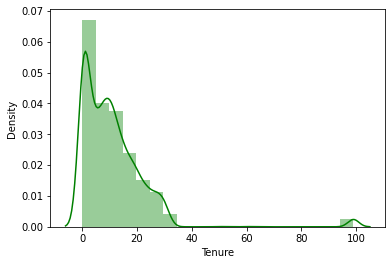

BoxPlot of Tenure
----------------------------------------------------------------------------


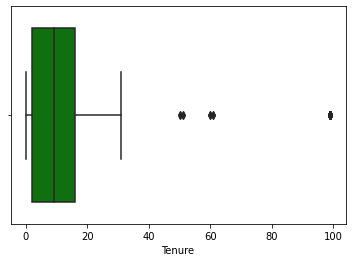

Description of CC_Contacted_LY
----------------------------------------------------------------------------
count    10952.000000
mean        17.904127
std          8.833205
min          4.000000
25%         11.000000
50%         16.000000
75%         23.000000
max        132.000000
Name: CC_Contacted_LY, dtype: float64

Skewness of CC_Contacted_LY is  1.44

Distribution of CC_Contacted_LY
----------------------------------------------------------------------------


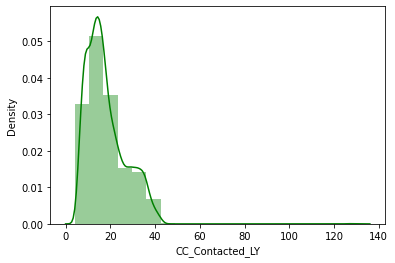

BoxPlot of CC_Contacted_LY
----------------------------------------------------------------------------


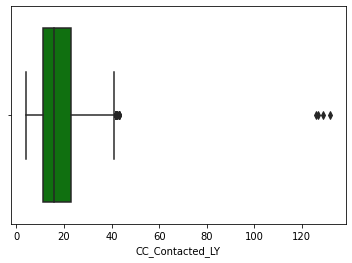

Description of Account_user_count
----------------------------------------------------------------------------
count    10952.000000
mean         3.988587
std          1.756098
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max         11.000000
Name: Account_user_count, dtype: float64

Skewness of Account_user_count is  2.34

Distribution of Account_user_count
----------------------------------------------------------------------------


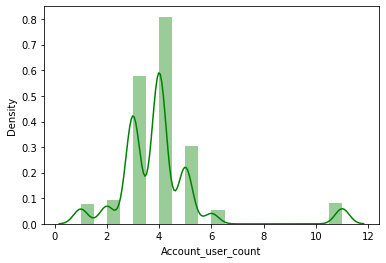

BoxPlot of Account_user_count
----------------------------------------------------------------------------


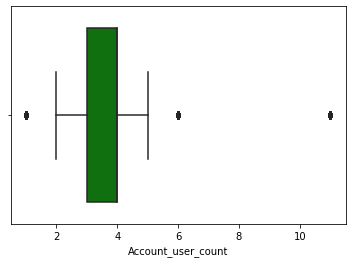

Description of rev_per_month
----------------------------------------------------------------------------
count    10952.000000
mean         6.388879
std         11.631297
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max        140.000000
Name: rev_per_month, dtype: float64

Skewness of rev_per_month is  9.33

Distribution of rev_per_month
----------------------------------------------------------------------------


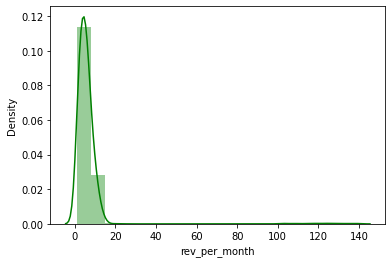

BoxPlot of rev_per_month
----------------------------------------------------------------------------


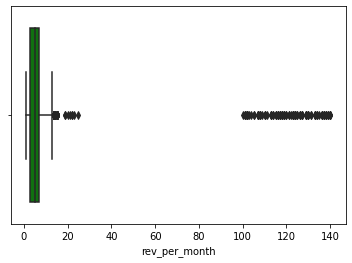

Description of rev_growth_yoy
----------------------------------------------------------------------------
count    10952.000000
mean        16.210099
std          3.761247
min          4.000000
25%         13.000000
50%         15.000000
75%         19.000000
max         28.000000
Name: rev_growth_yoy, dtype: float64

Skewness of rev_growth_yoy is  0.75

Distribution of rev_growth_yoy
----------------------------------------------------------------------------


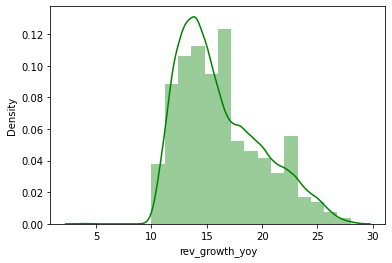

BoxPlot of rev_growth_yoy
----------------------------------------------------------------------------


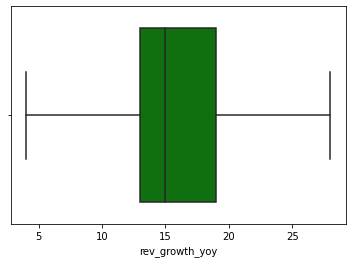

Description of coupon_used_for_payment
----------------------------------------------------------------------------
count    10952.000000
mean         1.804693
std          1.979929
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         16.000000
Name: coupon_used_for_payment, dtype: float64

Skewness of coupon_used_for_payment is  2.55

Distribution of coupon_used_for_payment
----------------------------------------------------------------------------


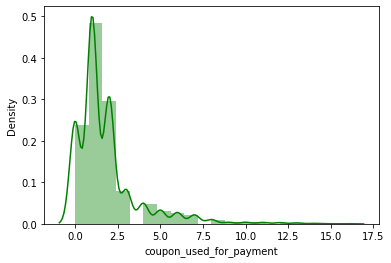

BoxPlot of coupon_used_for_payment
----------------------------------------------------------------------------


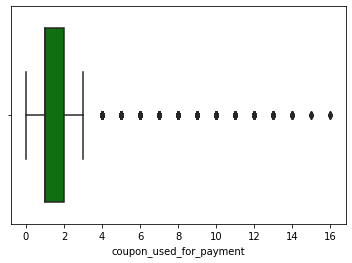

Description of Day_Since_CC_connect
----------------------------------------------------------------------------
count    10952.000000
mean         4.665175
std          3.644448
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         47.000000
Name: Day_Since_CC_connect, dtype: float64

Skewness of Day_Since_CC_connect is  1.29

Distribution of Day_Since_CC_connect
----------------------------------------------------------------------------


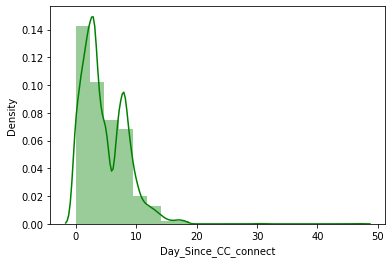

BoxPlot of Day_Since_CC_connect
----------------------------------------------------------------------------


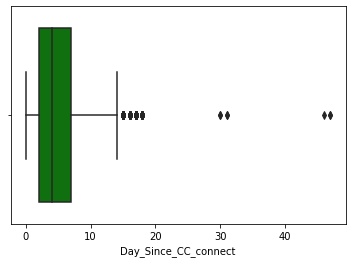

Description of cashback
----------------------------------------------------------------------------
count    10952.000000
mean       196.558072
std        177.141454
min          0.000000
25%        148.000000
50%        167.000000
75%        198.000000
max       1997.000000
Name: cashback, dtype: float64

Skewness of cashback is  8.86

Distribution of cashback
----------------------------------------------------------------------------


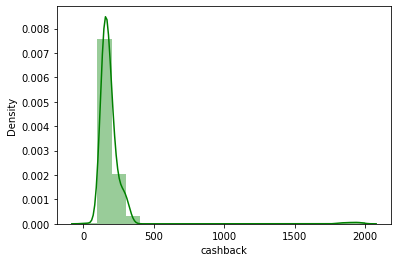

BoxPlot of cashback
----------------------------------------------------------------------------


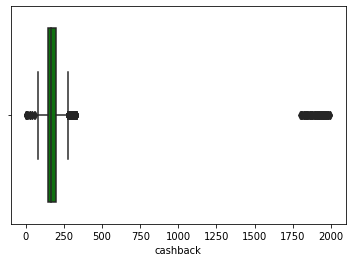

In [69]:
for x in lstnumericcolumns:
    univariateAnalysis_numeric(x,20)

In [70]:
## Value count and bbar chart of categorical variables

def univariateAnalysis_category(cat_column):
    print("Details of " + cat_column)
    print("----------------------------------------------------------------")
    print(churn_cat[cat_column].value_counts())
    plt.figure()
    churn_cat[cat_column].value_counts().plot.bar(title="Frequency Distribution of " + cat_column)
    plt.show()
    print("       ")

In [71]:
lstcatcolumns = list(churn_cat.columns.values)
lstcatcolumns

['Churn',
 'City_Tier',
 'Payment',
 'Gender',
 'Service_Score',
 'account_segment',
 'CC_Agent_Score',
 'Marital_Status',
 'Complain_ly',
 'Login_device']

Details of Churn
----------------------------------------------------------------
0    9108
1    1844
Name: Churn, dtype: int64


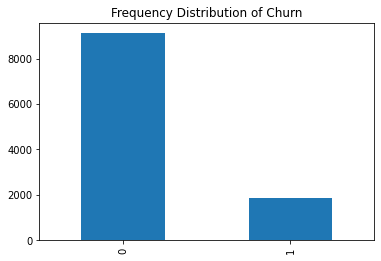

       
Details of City_Tier
----------------------------------------------------------------
1.0    7177
3.0    3321
2.0     454
Name: City_Tier, dtype: int64


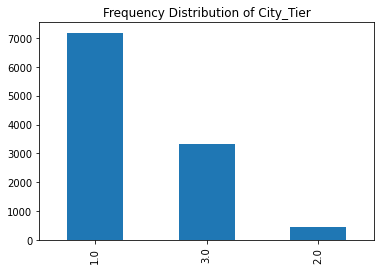

       
Details of Payment
----------------------------------------------------------------
Debit Card          4570
Credit Card         3427
E wallet            1189
Cash on Delivery     972
UPI                  794
Name: Payment, dtype: int64


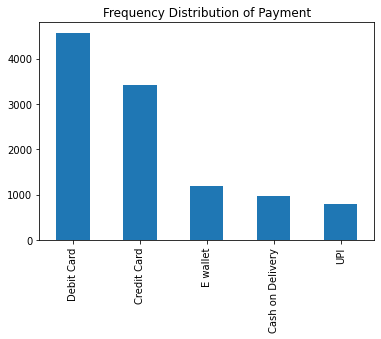

       
Details of Gender
----------------------------------------------------------------
Male      6626
Female    4326
Name: Gender, dtype: int64


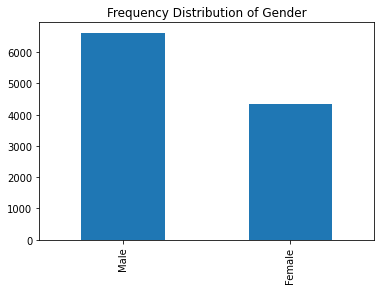

       
Details of Service_Score
----------------------------------------------------------------
3.0    5427
2.0    3173
4.0    2263
1.0      76
0.0       8
5.0       5
Name: Service_Score, dtype: int64


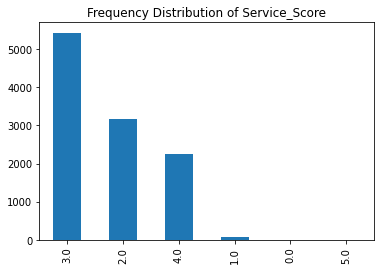

       
Details of account_segment
----------------------------------------------------------------
Regular Plus    4090
Super           3939
HNI             1612
Super Plus       801
Regular          510
Name: account_segment, dtype: int64


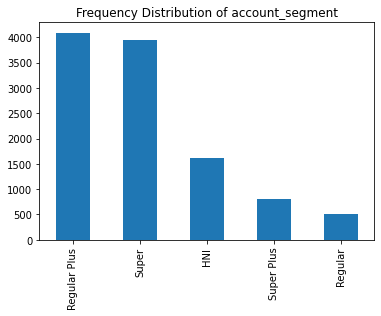

       
Details of CC_Agent_Score
----------------------------------------------------------------
3.0    3369
1.0    2257
5.0    2109
4.0    2053
2.0    1164
Name: CC_Agent_Score, dtype: int64


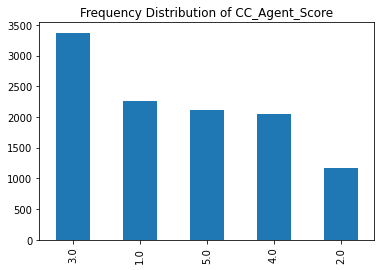

       
Details of Marital_Status
----------------------------------------------------------------
Married     5890
Single      3394
Divorced    1668
Name: Marital_Status, dtype: int64


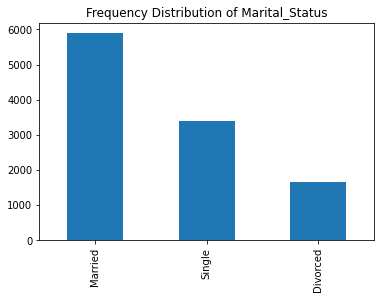

       
Details of Complain_ly
----------------------------------------------------------------
0.0    7926
1.0    3026
Name: Complain_ly, dtype: int64


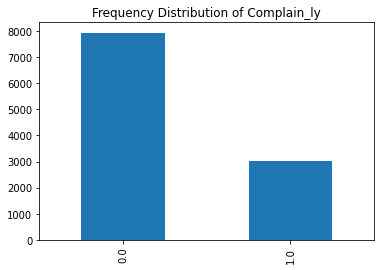

       
Details of Login_device
----------------------------------------------------------------
Mobile      8027
Computer    2925
Name: Login_device, dtype: int64


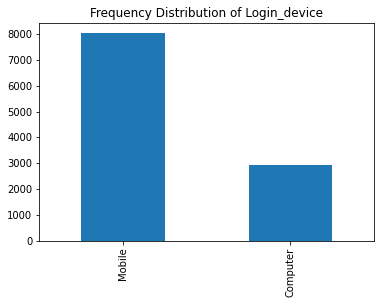

In [72]:
for x in lstcatcolumns:
    univariateAnalysis_category(x)

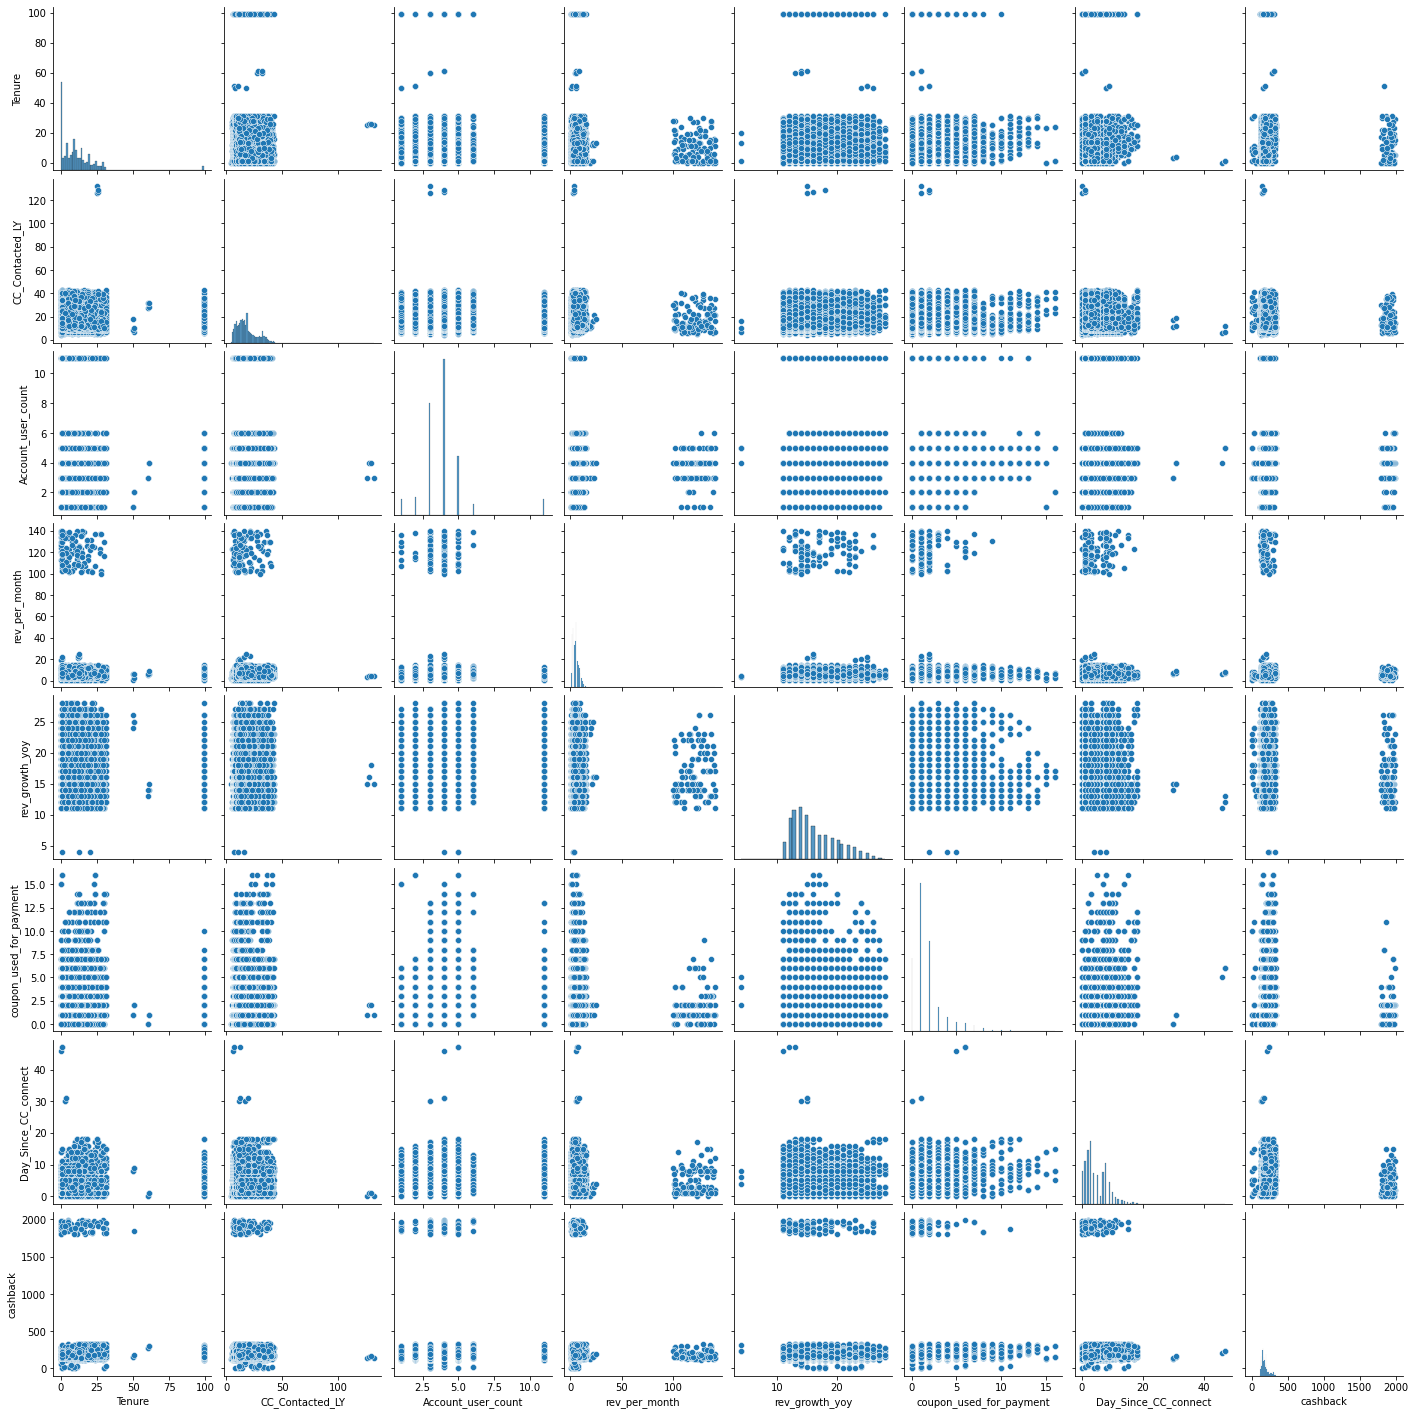

In [73]:
sns.pairplot(churn_num);

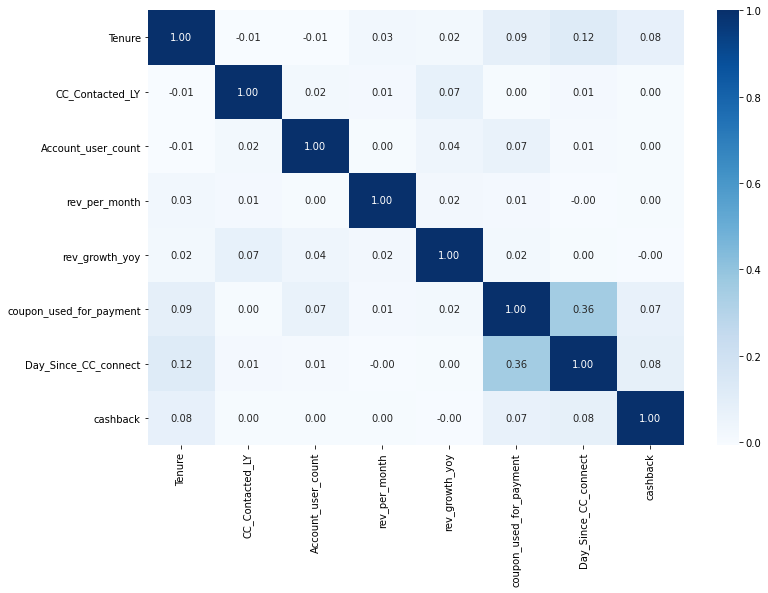

In [74]:
plt.figure(figsize = (12,8))
sns.heatmap(churn.corr(), annot = True, cmap = 'Blues',fmt = '.2f');

### Bivariate Analysis

In [75]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10952 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Churn                    10952 non-null  object
 1   Tenure                   10952 non-null  int32 
 2   City_Tier                10952 non-null  object
 3   CC_Contacted_LY          10952 non-null  int32 
 4   Payment                  10952 non-null  object
 5   Gender                   10952 non-null  object
 6   Service_Score            10952 non-null  object
 7   Account_user_count       10952 non-null  int32 
 8   account_segment          10952 non-null  object
 9   CC_Agent_Score           10952 non-null  object
 10  Marital_Status           10952 non-null  object
 11  rev_per_month            10952 non-null  int32 
 12  Complain_ly              10952 non-null  object
 13  rev_growth_yoy           10952 non-null  int32 
 14  coupon_used_for_payment  10952 non-nul

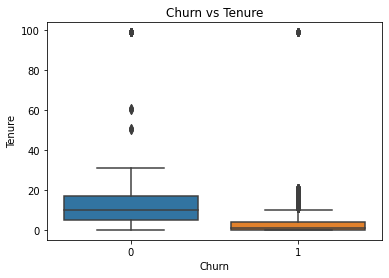

In [76]:
## Tenure of Account and churn

sns.boxplot(x='Churn', y='Tenure', data = churn);
plt.title('Churn vs Tenure')
plt.show()

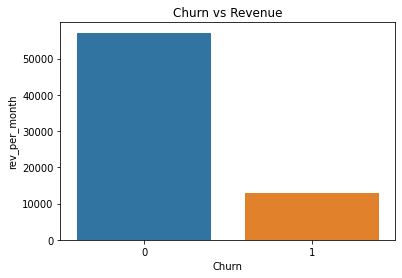

In [77]:
## Revenue of Account and churn

sns.barplot(x='Churn', y='rev_per_month', data = churn, ci=None, estimator = np.sum);
plt.title('Churn vs Revenue')
plt.show()

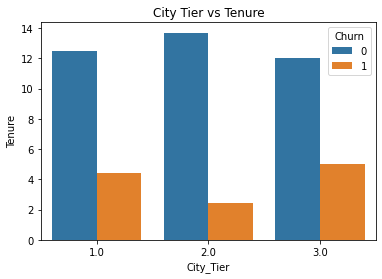

In [78]:
## City tier, Churn & Tenure

sns.barplot(x='City_Tier', y='Tenure', hue = 'Churn', data=churn, ci=None);
plt.title('City Tier vs Tenure')
plt.show()

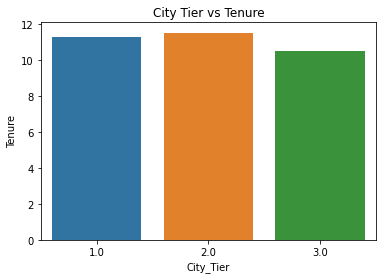

In [79]:
sns.barplot(x='City_Tier', y='Tenure', data=churn, ci=None);
plt.title('City Tier vs Tenure')
plt.show()

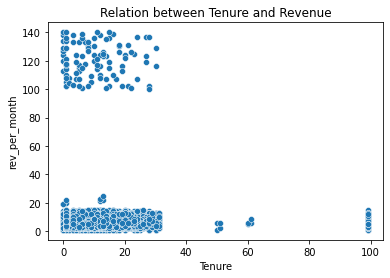

In [80]:
## Tenure vs Revenue

sns.scatterplot(churn['Tenure'], churn['rev_per_month']);
plt.title('Relation between Tenure and Revenue')
plt.show()

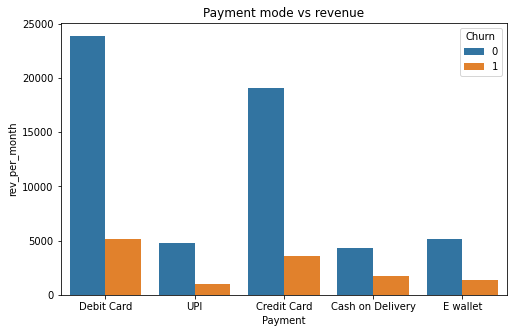

In [81]:
## Payment Mode vs churn

plt.figure(figsize=(8,5))
sns.barplot(x='Payment', y='rev_per_month', hue='Churn', data=churn, ci=None, estimator=np.sum);
plt.title('Payment mode vs revenue')
plt.show()

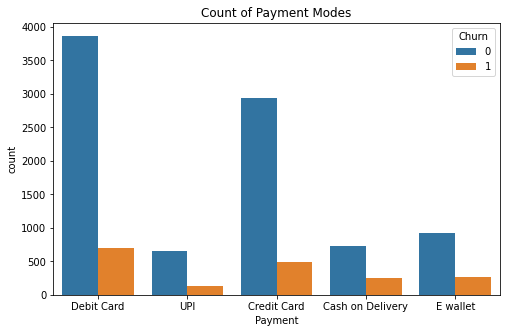

In [82]:
plt.figure(figsize=(8,5))
sns.countplot(churn['Payment'], hue=churn['Churn']);
plt.title('Count of Payment Modes')
plt.show()

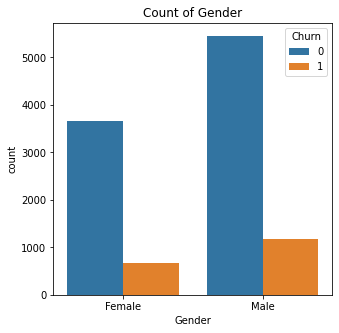

In [83]:
## Gender vs churn

plt.figure(figsize=(5,5))
sns.countplot(churn['Gender'], hue=churn['Churn']);
plt.title('Count of Gender')
plt.show()

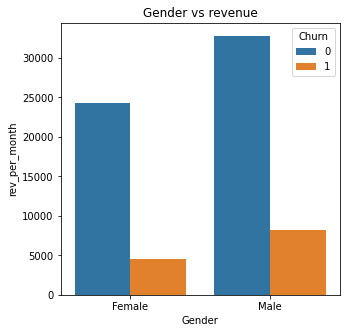

In [84]:
## Gender vs churn

plt.figure(figsize=(5,5))
sns.barplot(x='Gender', y='rev_per_month', hue='Churn', data=churn, ci=None, estimator=np.sum);
plt.title('Gender vs revenue')
plt.show()

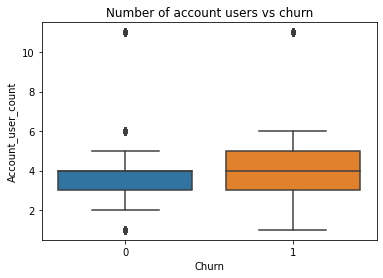

In [85]:
## No. of account users vs churn

sns.boxplot(x='Churn', y='Account_user_count', data=churn);
plt.title('Number of account users vs churn')
plt.show()

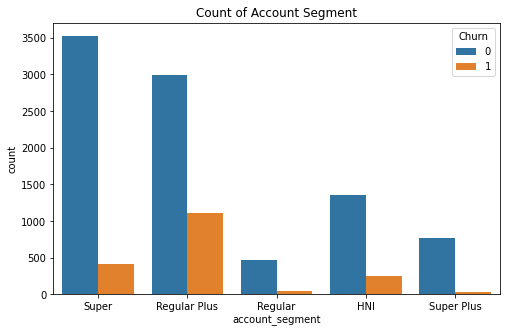

In [86]:
## Account Segment vs churn count

plt.figure(figsize=(8,5))
sns.countplot(churn['account_segment'], hue=churn['Churn']);
plt.title('Count of Account Segment')
plt.show()

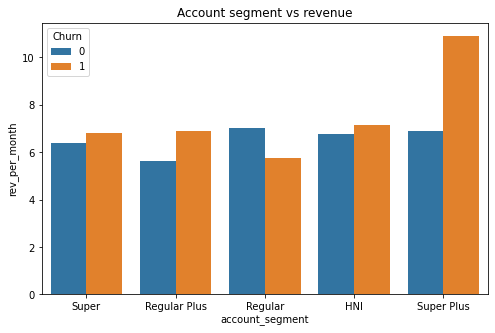

In [87]:
## Account segment vs churn revenue

plt.figure(figsize=(8,5))
sns.barplot(x='account_segment', y='rev_per_month', hue='Churn', data=churn, ci=None);
plt.title('Account segment vs revenue')
plt.show()

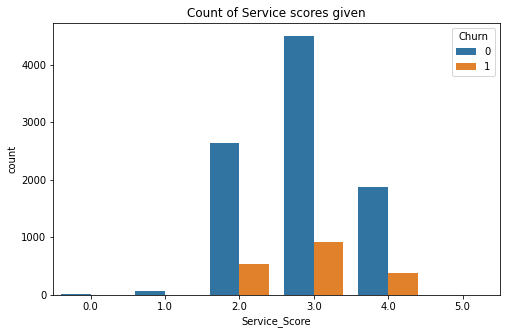

In [88]:
## Service score vs churn count

plt.figure(figsize=(8,5))
sns.countplot(churn['Service_Score'], hue=churn['Churn']);
plt.title('Count of Service scores given')
plt.show()

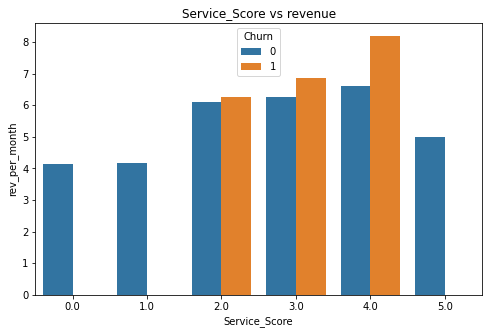

In [89]:
## Service score vs churn revenue

plt.figure(figsize=(8,5))
sns.barplot(x='Service_Score', y='rev_per_month', hue='Churn', data=churn, ci=None);
plt.title('Service_Score vs revenue')
plt.show()

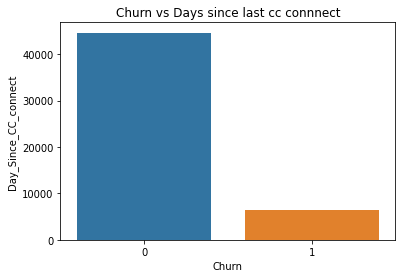

In [90]:
## Days since last connect vs churn

sns.barplot(x='Churn', y='Day_Since_CC_connect', data = churn, ci=None,estimator =np.sum);
plt.title('Churn vs Days since last cc connnect')
plt.show()

#### Clustering

In [91]:
churn_clust = churn.copy()

In [92]:
churn_clust.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4,3.0,6,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159,Mobile
1,1,0,1.0,8,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120,Mobile
2,1,0,1.0,30,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,196,Mobile
3,1,0,3.0,15,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134,Mobile
4,1,0,1.0,12,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129,Mobile


In [93]:
churn_clust.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10952 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Churn                    10952 non-null  object
 1   Tenure                   10952 non-null  int32 
 2   City_Tier                10952 non-null  object
 3   CC_Contacted_LY          10952 non-null  int32 
 4   Payment                  10952 non-null  object
 5   Gender                   10952 non-null  object
 6   Service_Score            10952 non-null  object
 7   Account_user_count       10952 non-null  int32 
 8   account_segment          10952 non-null  object
 9   CC_Agent_Score           10952 non-null  object
 10  Marital_Status           10952 non-null  object
 11  rev_per_month            10952 non-null  int32 
 12  Complain_ly              10952 non-null  object
 13  rev_growth_yoy           10952 non-null  int32 
 14  coupon_used_for_payment  10952 non-nul

In [94]:
churn_clust['Churn'] = churn_clust['Churn'].astype(int)
churn_clust['City_Tier'] = churn_clust['City_Tier'].astype(int)
churn_clust['Service_Score'] = churn_clust['Service_Score'].astype(int)
churn_clust['CC_Agent_Score'] = churn_clust['CC_Agent_Score'].astype(int)
churn_clust['Complain_ly'] = churn_clust['Complain_ly'].astype(int)

In [95]:
churn_clust.dtypes

Churn                       int32
Tenure                      int32
City_Tier                   int32
CC_Contacted_LY             int32
Payment                    object
Gender                     object
Service_Score               int32
Account_user_count          int32
account_segment            object
CC_Agent_Score              int32
Marital_Status             object
rev_per_month               int32
Complain_ly                 int32
rev_growth_yoy              int32
coupon_used_for_payment     int32
Day_Since_CC_connect        int32
cashback                    int32
Login_device               object
dtype: object

In [96]:
churn_clust_cat = churn_clust.select_dtypes(['object', 'category'])

In [97]:
churn_clust_num = churn_clust.select_dtypes(['int32', 'int64', 'float64'])

In [98]:
churn_clust_cat = pd.get_dummies(churn_clust_cat, drop_first=True)

In [99]:
churn_clust_cat.head()

,Payment_Credit Card,Payment_Debit Card,Payment_E wallet,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,0,1,0,0,0,0,0,1,0,0,1,1
1,0,0,0,1,1,0,1,0,0,0,1,1
2,0,1,0,0,1,0,1,0,0,0,1,1
3,0,1,0,0,1,0,0,1,0,0,1,1
4,1,0,0,0,1,0,1,0,0,0,1,1


In [100]:
churn_clust = pd.concat([churn_clust_num, churn_clust_cat], axis=1)

In [101]:
churn_clust.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,...,Payment_E wallet,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,1,4,3,6,3,3,2,9,1,11,...,0,0,0,0,0,1,0,0,1,1
1,1,0,1,8,3,4,3,7,1,15,...,0,1,1,0,1,0,0,0,1,1
2,1,0,1,30,2,4,3,6,1,14,...,0,0,1,0,1,0,0,0,1,1
3,1,0,3,15,2,4,5,8,0,23,...,0,0,1,0,0,1,0,0,1,1
4,1,0,1,12,2,3,5,3,0,11,...,0,0,1,0,1,0,0,0,1,1


In [102]:
churn_clust.dtypes

Churn                           int32
Tenure                          int32
City_Tier                       int32
CC_Contacted_LY                 int32
Service_Score                   int32
Account_user_count              int32
CC_Agent_Score                  int32
rev_per_month                   int32
Complain_ly                     int32
rev_growth_yoy                  int32
coupon_used_for_payment         int32
Day_Since_CC_connect            int32
cashback                        int32
Payment_Credit Card             uint8
Payment_Debit Card              uint8
Payment_E wallet                uint8
Payment_UPI                     uint8
Gender_Male                     uint8
account_segment_Regular         uint8
account_segment_Regular Plus    uint8
account_segment_Super           uint8
account_segment_Super Plus      uint8
Marital_Status_Married          uint8
Marital_Status_Single           uint8
Login_device_Mobile             uint8
dtype: object

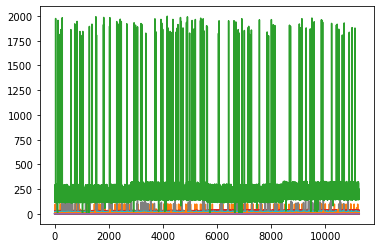

In [103]:
plt.plot(churn_clust)
plt.show()

In [104]:
from sklearn.preprocessing import StandardScaler

In [105]:
X = StandardScaler()
scaled_df = pd.DataFrame(X.fit_transform(churn_clust), columns=churn_clust.columns)

In [106]:
scaled_df.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,...,Payment_E wallet,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,2.222445,-0.550058,1.480021,-1.347718,0.135872,-0.562971,-0.767713,0.224501,1.618425,-1.385268,...,-0.348979,-0.279580,-1.237606,-0.221,-0.772034,1.334317,-0.280907,-1.07869,1.49227,0.603652
1,2.222445,-0.861071,-0.709226,-1.121289,0.135872,0.006500,-0.039433,0.052544,1.618425,-0.321743,...,-0.348979,3.576793,0.808011,-0.221,1.295280,-0.749447,-0.280907,-1.07869,1.49227,0.603652
2,2.222445,-0.861071,-0.709226,1.369427,-1.247090,0.006500,-0.039433,-0.033435,1.618425,-0.587624,...,-0.348979,-0.279580,0.808011,-0.221,1.295280,-0.749447,-0.280907,-1.07869,1.49227,0.603652
3,2.222445,-0.861071,1.480021,-0.328789,-1.247090,0.006500,1.417127,0.138522,-0.617885,1.805309,...,-0.348979,-0.279580,0.808011,-0.221,-0.772034,1.334317,-0.280907,-1.07869,1.49227,0.603652
4,2.222445,-0.861071,-0.709226,-0.668432,-1.247090,-0.562971,1.417127,-0.291372,-0.617885,-1.385268,...,-0.348979,-0.279580,0.808011,-0.221,1.295280,-0.749447,-0.280907,-1.07869,1.49227,0.603652


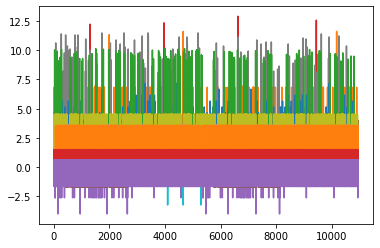

In [107]:
plt.plot(scaled_df)
plt.show()

In [108]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [109]:
wardlink = linkage(scaled_df, method = 'ward')

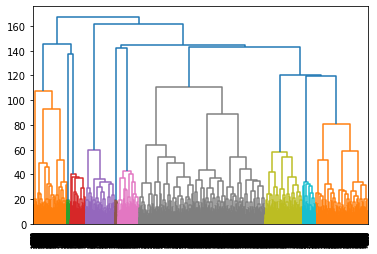

In [110]:
dend = dendrogram(wardlink)

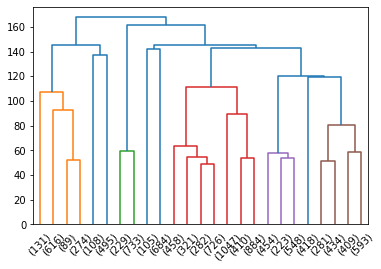

In [111]:
dend = dendrogram(wardlink, truncate_mode='lastp', p=25)

In [112]:
from scipy.cluster.hierarchy import fcluster

In [113]:
clusters = fcluster(wardlink, 5, criterion='maxclust')
clusters

array([5, 4, 5, ..., 5, 5, 5], dtype=int32)

In [114]:
churn_clust['clusters'] = clusters

In [115]:
churn_clust.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,...,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile,clusters
0,1,4,3,6,3,3,2,9,1,11,...,0,0,0,0,1,0,0,1,1,5
1,1,0,1,8,3,4,3,7,1,15,...,1,1,0,1,0,0,0,1,1,4
2,1,0,1,30,2,4,3,6,1,14,...,0,1,0,1,0,0,0,1,1,5
3,1,0,3,15,2,4,5,8,0,23,...,0,1,0,0,1,0,0,1,1,5
4,1,0,1,12,2,3,5,3,0,11,...,0,1,0,1,0,0,0,1,1,5


In [116]:
churn_clust['clusters'].value_counts()

5    7488
1    1110
3     962
4     789
2     603
Name: clusters, dtype: int64

In [117]:
aggdata=churn_clust.groupby('clusters').mean()
aggdata['Freq']=churn_clust.clusters.value_counts().sort_index()
aggdata

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,...,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile,Freq
clusters,,,,,,,,,,,,,,,,,,,,,
1,0.080180,27.556757,1.736036,18.065766,2.865766,3.718919,3.049550,5.538739,0.242342,16.341441,...,0.006306,0.501802,0.004505,0.069369,0.150450,0.648649,0.565766,0.238739,0.725225,1110
2,0.097844,18.233831,1.500829,15.648425,2.862355,3.976783,3.038143,5.716418,0.257048,15.532338,...,0.097844,0.733002,0.829187,0.066335,0.064677,0.019900,0.582090,0.235489,0.817579,603
3,0.238046,8.888773,2.981289,18.666320,2.903326,3.733888,3.142412,5.112266,0.302495,15.806653,...,0.000000,0.589397,0.000000,0.165281,0.607069,0.000000,0.543659,0.295218,0.739085,962
4,0.190114,8.250951,1.538657,17.858048,2.828897,3.741445,3.191381,20.518378,0.305450,16.283904,...,0.883397,0.642586,0.006337,0.442332,0.380228,0.050697,0.583016,0.278834,0.711027,789
5,0.175881,8.632879,1.486912,17.968750,2.917735,4.088275,3.030315,5.244257,0.276442,16.289263,...,0.004140,0.608040,0.000000,0.462740,0.380475,0.003873,0.524573,0.331597,0.728766,7488


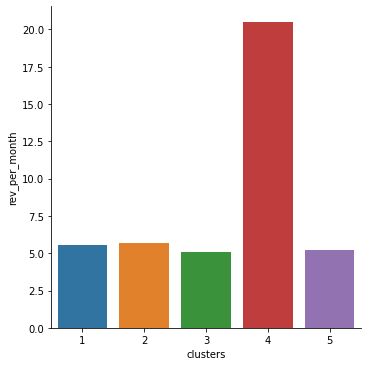

In [118]:
sns.catplot(x='clusters',y='rev_per_month',data=churn_clust, kind='bar', ci=None);

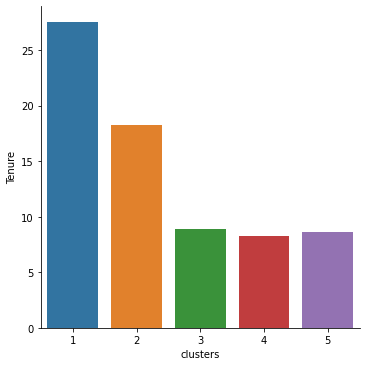

In [119]:
sns.catplot(x='clusters',y='Tenure',data=churn_clust, kind='bar', ci=None);

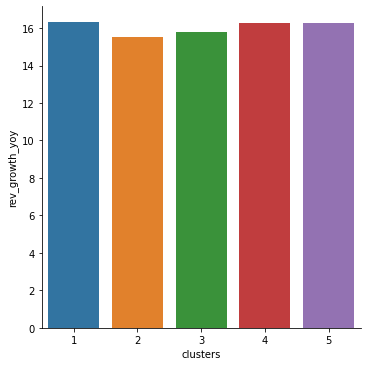

In [120]:
sns.catplot(x='clusters',y='rev_growth_yoy',data=churn_clust, kind='bar', ci=None);

### Outlier Treatment

In [121]:
churn.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4,3.0,6,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159,Mobile
1,1,0,1.0,8,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120,Mobile
2,1,0,1.0,30,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,196,Mobile
3,1,0,3.0,15,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134,Mobile
4,1,0,1.0,12,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129,Mobile


In [122]:
churn.dtypes

Churn                      object
Tenure                      int32
City_Tier                  object
CC_Contacted_LY             int32
Payment                    object
Gender                     object
Service_Score              object
Account_user_count          int32
account_segment            object
CC_Agent_Score             object
Marital_Status             object
rev_per_month               int32
Complain_ly                object
rev_growth_yoy              int32
coupon_used_for_payment     int32
Day_Since_CC_connect        int32
cashback                    int32
Login_device               object
dtype: object

In [123]:
churn_num.head()

,Tenure,CC_Contacted_LY,Account_user_count,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback
0,4,6,3,9,11,1,5,159
1,0,8,4,7,15,0,0,120
2,0,30,4,6,14,0,3,196
3,0,15,4,8,23,0,3,134
4,0,12,3,3,11,1,3,129


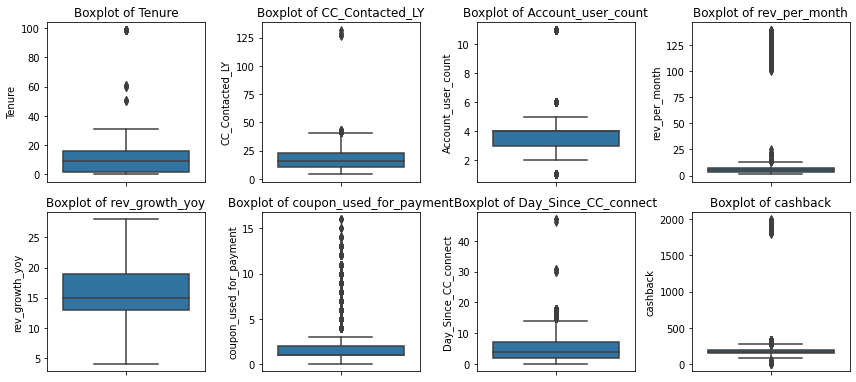

In [124]:
# Boxplots of all numerical columns

plt.figure(figsize = (12,8))
feature_list = churn_num.columns
for i in range(len(feature_list)):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y = churn_num[feature_list[i]], data = churn_num)
    plt.title('Boxplot of {}'.format(feature_list[i]))
    plt.tight_layout()

In [125]:
def treat_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [126]:
for column in churn_num.columns:
    lr,ur=treat_outlier(churn[column])
    churn[column]=np.where(churn[column]>ur,ur,churn[column])
    churn[column]=np.where(churn[column]<lr,lr,churn[column])

In [127]:
churn.dtypes

Churn                       object
Tenure                     float64
City_Tier                   object
CC_Contacted_LY            float64
Payment                     object
Gender                      object
Service_Score               object
Account_user_count         float64
account_segment             object
CC_Agent_Score              object
Marital_Status              object
rev_per_month              float64
Complain_ly                 object
rev_growth_yoy             float64
coupon_used_for_payment    float64
Day_Since_CC_connect       float64
cashback                   float64
Login_device                object
dtype: object

In [128]:
churn_num = churn.select_dtypes(['float64','int64'])

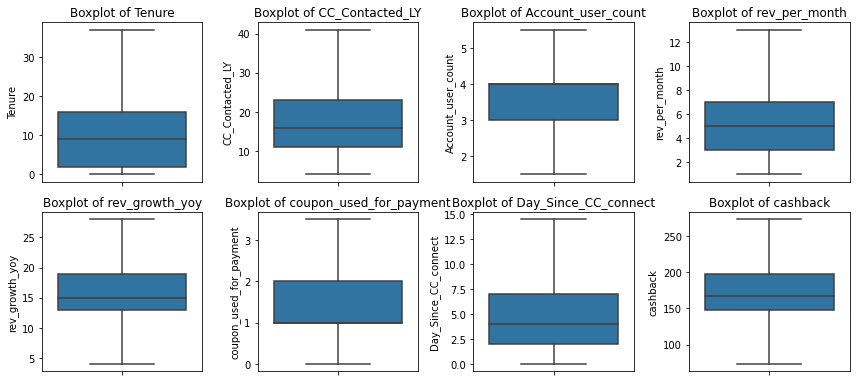

In [129]:
# Boxplots of all numerical columns

plt.figure(figsize = (12,8))
feature_list = churn_num.columns
for i in range(len(feature_list)):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y = churn_num[feature_list[i]], data = churn_num)
    plt.title('Boxplot of {}'.format(feature_list[i]))
    plt.tight_layout()

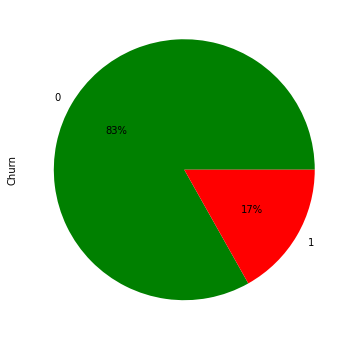

In [130]:
plt.figure(figsize=(8,6))
churn.Churn.value_counts().plot(kind='pie', autopct='%1.0f%%', colors=["green","red"])
plt.show()

In [131]:
churn['Churn'].value_counts()

0    9108
1    1844
Name: Churn, dtype: int64

# Note 2

In [132]:
churn.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.0,3.0,6.0,Debit Card,Female,3.0,3.0,Super,2.0,Single,9.0,1.0,11.0,1.0,5.0,159.0,Mobile
1,1,0.0,1.0,8.0,UPI,Male,3.0,4.0,Regular Plus,3.0,Single,7.0,1.0,15.0,0.0,0.0,120.0,Mobile
2,1,0.0,1.0,30.0,Debit Card,Male,2.0,4.0,Regular Plus,3.0,Single,6.0,1.0,14.0,0.0,3.0,196.0,Mobile
3,1,0.0,3.0,15.0,Debit Card,Male,2.0,4.0,Super,5.0,Single,8.0,0.0,23.0,0.0,3.0,134.0,Mobile
4,1,0.0,1.0,12.0,Credit Card,Male,2.0,3.0,Regular Plus,5.0,Single,3.0,0.0,11.0,1.0,3.0,129.0,Mobile


In [133]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10952 entries, 0 to 11259
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    10952 non-null  object 
 1   Tenure                   10952 non-null  float64
 2   City_Tier                10952 non-null  object 
 3   CC_Contacted_LY          10952 non-null  float64
 4   Payment                  10952 non-null  object 
 5   Gender                   10952 non-null  object 
 6   Service_Score            10952 non-null  object 
 7   Account_user_count       10952 non-null  float64
 8   account_segment          10952 non-null  object 
 9   CC_Agent_Score           10952 non-null  object 
 10  Marital_Status           10952 non-null  object 
 11  rev_per_month            10952 non-null  float64
 12  Complain_ly              10952 non-null  object 
 13  rev_growth_yoy           10952 non-null  float64
 14  coupon_used_for_paymen

### Encoding of variables

In [134]:
churn_clust.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,...,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile,clusters
0,1,4,3,6,3,3,2,9,1,11,...,0,0,0,0,1,0,0,1,1,5
1,1,0,1,8,3,4,3,7,1,15,...,1,1,0,1,0,0,0,1,1,4
2,1,0,1,30,2,4,3,6,1,14,...,0,1,0,1,0,0,0,1,1,5
3,1,0,3,15,2,4,5,8,0,23,...,0,1,0,0,1,0,0,1,1,5
4,1,0,1,12,2,3,5,3,0,11,...,0,1,0,1,0,0,0,1,1,5


In [135]:
churn_encoded = churn_clust.drop('clusters', axis=1)

In [136]:
churn_encoded.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,rev_growth_yoy,...,Payment_E wallet,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular Plus,account_segment_Super,account_segment_Super Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,1,4,3,6,3,3,2,9,1,11,...,0,0,0,0,0,1,0,0,1,1
1,1,0,1,8,3,4,3,7,1,15,...,0,1,1,0,1,0,0,0,1,1
2,1,0,1,30,2,4,3,6,1,14,...,0,0,1,0,1,0,0,0,1,1
3,1,0,3,15,2,4,5,8,0,23,...,0,0,1,0,0,1,0,0,1,1
4,1,0,1,12,2,3,5,3,0,11,...,0,0,1,0,1,0,0,0,1,1


In [137]:
churn_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10952 entries, 0 to 11259
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Churn                         10952 non-null  int32
 1   Tenure                        10952 non-null  int32
 2   City_Tier                     10952 non-null  int32
 3   CC_Contacted_LY               10952 non-null  int32
 4   Service_Score                 10952 non-null  int32
 5   Account_user_count            10952 non-null  int32
 6   CC_Agent_Score                10952 non-null  int32
 7   rev_per_month                 10952 non-null  int32
 8   Complain_ly                   10952 non-null  int32
 9   rev_growth_yoy                10952 non-null  int32
 10  coupon_used_for_payment       10952 non-null  int32
 11  Day_Since_CC_connect          10952 non-null  int32
 12  cashback                      10952 non-null  int32
 13  Payment_Credit Card           1

### Check VIF scores of variables

In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [139]:
X = churn_encoded.drop('Churn', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
3,Service_Score,16.979581
8,rev_growth_yoy,16.595504
4,Account_user_count,6.261685
1,City_Tier,5.654682
5,CC_Agent_Score,5.559891
13,Payment_Debit Card,5.098017
2,CC_Contacted_LY,5.040522
21,Marital_Status_Married,4.254233
12,Payment_Credit Card,4.092744
23,Login_device_Mobile,3.657992


In [140]:
X = X.drop('Service_Score', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
7,rev_growth_yoy,15.501017
3,Account_user_count,5.895273
1,City_Tier,5.597627
4,CC_Agent_Score,5.460139
12,Payment_Debit Card,4.996017
2,CC_Contacted_LY,4.971076
20,Marital_Status_Married,4.220437
11,Payment_Credit Card,4.027575
22,Login_device_Mobile,3.638623
17,account_segment_Regular Plus,3.519178


In [141]:
X = X.drop('rev_growth_yoy', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
3,Account_user_count,5.714232
1,City_Tier,5.468909
4,CC_Agent_Score,5.349628
2,CC_Contacted_LY,4.783705
11,Payment_Debit Card,4.679224
19,Marital_Status_Married,4.093130
10,Payment_Credit Card,3.771836
21,Login_device_Mobile,3.603683
16,account_segment_Regular Plus,3.317731
8,Day_Since_CC_connect,3.216256


In [142]:
X = X.drop('Account_user_count', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
1,City_Tier,5.417094
3,CC_Agent_Score,5.311112
2,CC_Contacted_LY,4.728053
10,Payment_Debit Card,4.601995
18,Marital_Status_Married,4.034003
9,Payment_Credit Card,3.711918
20,Login_device_Mobile,3.532625
15,account_segment_Regular Plus,3.256678
7,Day_Since_CC_connect,3.204891
16,account_segment_Super,3.152944


In [143]:
X = X.drop('City_Tier', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
2,CC_Agent_Score,5.246524
1,CC_Contacted_LY,4.690100
9,Payment_Debit Card,4.484743
17,Marital_Status_Married,3.986467
8,Payment_Credit Card,3.661270
19,Login_device_Mobile,3.507967
14,account_segment_Regular Plus,3.253406
6,Day_Since_CC_connect,3.201467
15,account_segment_Super,3.051661
18,Marital_Status_Single,2.693131


In [144]:
X = X.drop('CC_Agent_Score', axis = 1)
calc_vif(X).sort_values(by = 'VIF', ascending = False)

,variables,VIF
1,CC_Contacted_LY,4.613740
8,Payment_Debit Card,4.361563
16,Marital_Status_Married,3.958026
7,Payment_Credit Card,3.542424
18,Login_device_Mobile,3.439707
5,Day_Since_CC_connect,3.154222
13,account_segment_Regular Plus,3.124178
14,account_segment_Super,2.988848
17,Marital_Status_Single,2.675710
11,Gender_Male,2.484837


### Train-Test Split

In [145]:
from sklearn.model_selection import train_test_split

In [146]:
y = churn_encoded['Churn']

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [148]:
print('Shape of X_train is ', X_train.shape)
print('Shape of X_test is ', X_test.shape)
print('Shape of y_train is ', y_train.shape)
print('Shape of y_test is ', y_test.shape)

Shape of X_train is  (7666, 19)
Shape of X_test is  (3286, 19)
Shape of y_train is  (7666,)
Shape of y_test is  (3286,)


### SMOTE

In [149]:
y_train.value_counts(normalize=True)

0    0.83042
1    0.16958
Name: Churn, dtype: float64

In [150]:
from imblearn.over_sampling import SMOTE

In [151]:
sm = SMOTE(random_state=1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())

In [152]:
y_train_res.shape

(12732,)

In [153]:
X_train_res.shape

(12732, 19)

In [154]:
y_train_res

array([0, 0, 0, ..., 1, 1, 1])

In [155]:
df = pd.DataFrame(data=y_train_res, columns=['Churn'])

In [156]:
df.value_counts()

Churn
0        6366
1        6366
dtype: int64

In [157]:
df.head()

,Churn
0,0
1,0
2,0
3,0
4,0


## Model 1 - Naive bayes

In [158]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [159]:
NB_SM_model = GaussianNB()
NB_SM_model.fit(X_train_res, y_train_res)

GaussianNB()

In [160]:
y_train_predict = NB_SM_model.predict(X_train_res)
y_test_predict = NB_SM_model.predict(X_test)

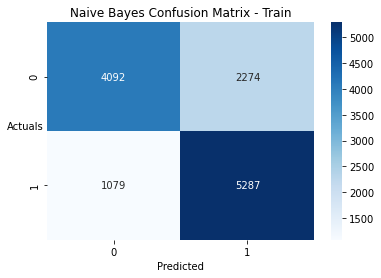

In [161]:
sns.heatmap((metrics.confusion_matrix(y_train_res, y_train_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Naive Bayes Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [162]:
print(metrics.classification_report(y_train_res, y_train_predict))

              precision    recall  f1-score   support

           0       0.79      0.64      0.71      6366
           1       0.70      0.83      0.76      6366

    accuracy                           0.74     12732
   macro avg       0.75      0.74      0.73     12732
weighted avg       0.75      0.74      0.73     12732



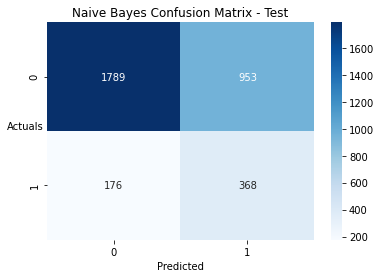

In [163]:
sns.heatmap((metrics.confusion_matrix(y_test, y_test_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Naive Bayes Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [164]:
print(metrics.classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.91      0.65      0.76      2742
           1       0.28      0.68      0.39       544

    accuracy                           0.66      3286
   macro avg       0.59      0.66      0.58      3286
weighted avg       0.81      0.66      0.70      3286



AUC: 0.820


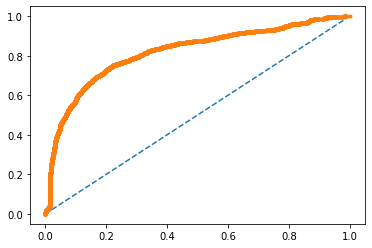

In [165]:
# AUC and ROC for the train data

# predict probabilities
probs = NB_SM_model.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.705


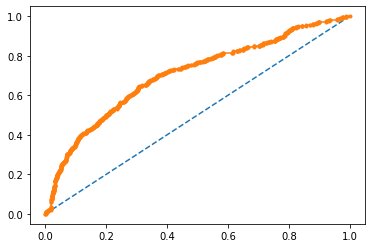

In [166]:
# AUC and ROC for the test data

# predict probabilities
probs = NB_SM_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Model 2 - KNN

In [167]:
from sklearn.neighbors import KNeighborsClassifier

In [168]:
KNN_SM_model=KNeighborsClassifier()
KNN_SM_model.fit(X_train_res,y_train_res)

KNeighborsClassifier()

In [169]:
y_train_predict =KNN_SM_model.predict(X_train_res)
y_test_predict = KNN_SM_model.predict(X_test)

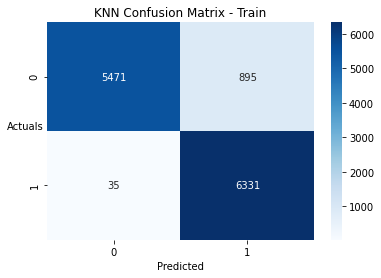

In [170]:
sns.heatmap((metrics.confusion_matrix(y_train_res, y_train_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('KNN Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [171]:
print(metrics.classification_report(y_train_res, y_train_predict))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      6366
           1       0.88      0.99      0.93      6366

    accuracy                           0.93     12732
   macro avg       0.93      0.93      0.93     12732
weighted avg       0.93      0.93      0.93     12732



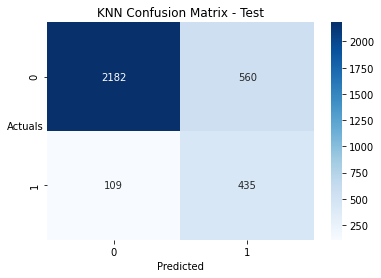

In [172]:
sns.heatmap((metrics.confusion_matrix(y_test, y_test_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('KNN Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [173]:
print(metrics.classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87      2742
           1       0.44      0.80      0.57       544

    accuracy                           0.80      3286
   macro avg       0.69      0.80      0.72      3286
weighted avg       0.87      0.80      0.82      3286



AUC: 0.995


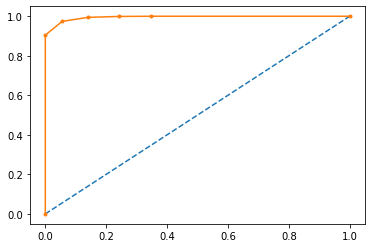

In [174]:
# AUC and ROC for the train data

# predict probabilities
probs = KNN_SM_model.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.867


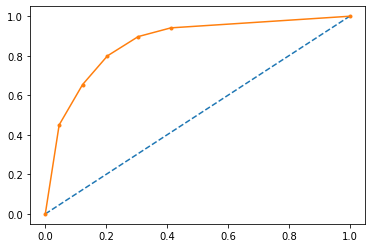

In [175]:
# AUC and ROC for the test data

# predict probabilities
probs = KNN_SM_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [176]:
# empty list that will hold accuracy scores
ac_scores = []

# perform accuracy metrics for values from 1,3,5....19
for k in range(1,20,2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_res, y_train_res)
    # evaluate test accuracy
    scores = knn.score(X_test, y_test)
    ac_scores.append(scores)

# changing to misclassification error
MCE = [1 - x for x in ac_scores]
MCE0.

[0.1494217894096166,
 0.1816798539257456,
 0.20359099208764453,
 0.2212416311625076,
 0.2251978088861838,
 0.23067559342665855,
 0.23706634205721244,
 0.23584905660377353,
 0.2401095556908095,
 0.243761412051126]

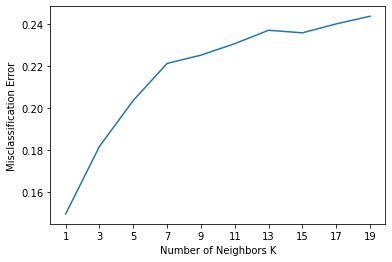

In [177]:
import matplotlib.pyplot as plt
# plot misclassification error vs k
plt.plot(range(1,20,2), MCE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.xticks(range(1,20,2))
plt.show()

In [178]:
NNH = KNeighborsClassifier(n_neighbors= 1)
NNH.fit(X_train_res, y_train_res)

KNeighborsClassifier(n_neighbors=1)

In [179]:
y_train_predict =NNH.predict(X_train_res)
y_test_predict = NNH.predict(X_test)

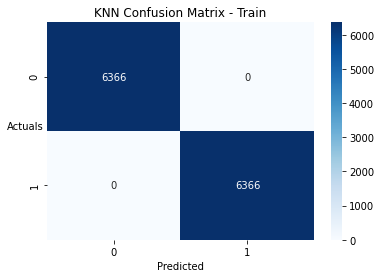

In [180]:
sns.heatmap((metrics.confusion_matrix(y_train_res, y_train_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('KNN Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [181]:
print(metrics.classification_report(y_train_res, y_train_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6366
           1       1.00      1.00      1.00      6366

    accuracy                           1.00     12732
   macro avg       1.00      1.00      1.00     12732
weighted avg       1.00      1.00      1.00     12732



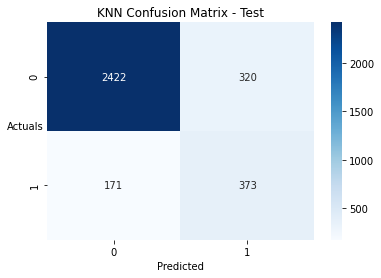

In [182]:
sns.heatmap((metrics.confusion_matrix(y_test, y_test_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('KNN Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [183]:
print(metrics.classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91      2742
           1       0.54      0.69      0.60       544

    accuracy                           0.85      3286
   macro avg       0.74      0.78      0.76      3286
weighted avg       0.87      0.85      0.86      3286



AUC: 1.000


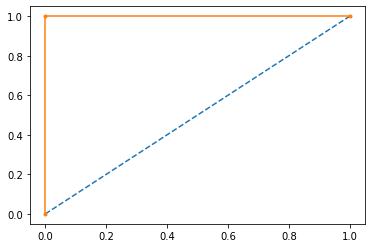

In [184]:
# AUC and ROC for the train data

# predict probabilities
probs = NNH.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.784


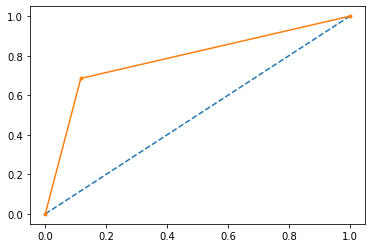

In [185]:
# AUC and ROC for the test data

# predict probabilities
probs = NNH.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Model 3 - Random Forest

In [186]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [238]:
param_grid = {
    'max_depth': [20],
    'max_features': [8],
    'min_samples_leaf': [150],
    'min_samples_split': [450],
    'n_estimators': [301]
}

rfcl = RandomForestClassifier()

grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid)

In [239]:
grid_search.fit(X_train_res, y_train_res)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [20], 'max_features': [8],
                         'min_samples_leaf': [150], 'min_samples_split': [450],
                         'n_estimators': [301]})

In [240]:
grid_search.best_params_

{'max_depth': 20,
 'max_features': 8,
 'min_samples_leaf': 150,
 'min_samples_split': 450,
 'n_estimators': 301}

In [241]:
best_grid_rf = grid_search.best_estimator_

In [335]:
ytrain_predict = best_grid_rf.predict(X_train_res)
ytest_predict = best_grid_rf.predict(X_test)

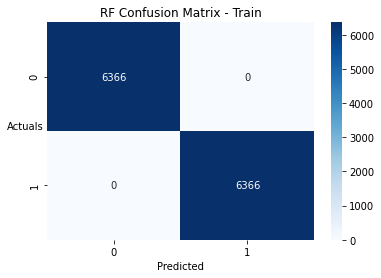

In [336]:
sns.heatmap((metrics.confusion_matrix(y_train_res, y_train_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('RF Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [337]:
print(metrics.classification_report(y_train_res, y_train_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6366
           1       1.00      1.00      1.00      6366

    accuracy                           1.00     12732
   macro avg       1.00      1.00      1.00     12732
weighted avg       1.00      1.00      1.00     12732



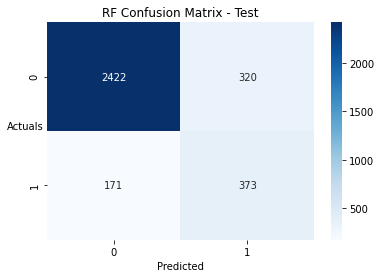

In [245]:
sns.heatmap((metrics.confusion_matrix(y_test, y_test_predict)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('RF Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [246]:
print(metrics.classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91      2742
           1       0.54      0.69      0.60       544

    accuracy                           0.85      3286
   macro avg       0.74      0.78      0.76      3286
weighted avg       0.87      0.85      0.86      3286



AUC: 0.927


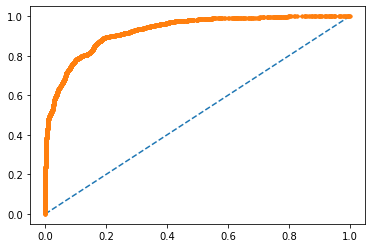

In [333]:
# AUC and ROC for the train data

# predict probabilities
probs = best_grid_rf.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.878


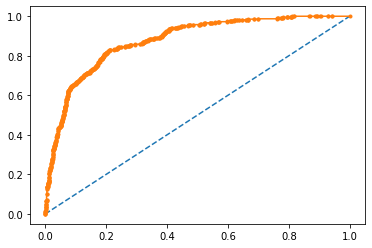

In [334]:
# AUC and ROC for the test data

# predict probabilities
probs = best_grid_rf.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

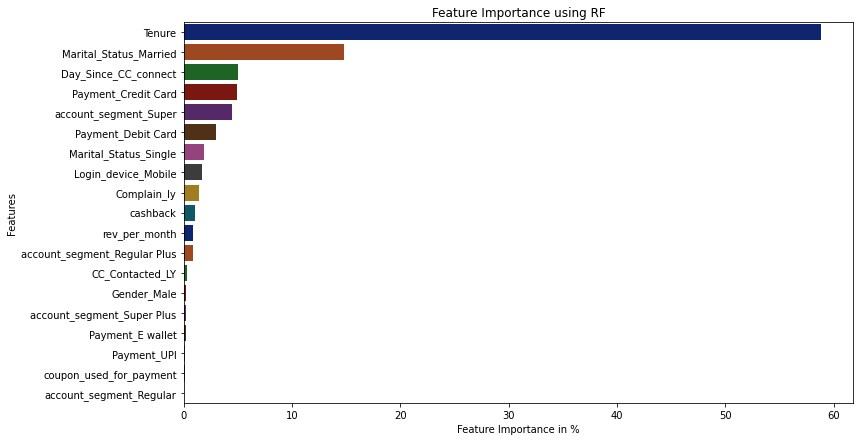

In [306]:
x=pd.DataFrame(best_grid_rf.feature_importances_*100,index=X_train_res.columns).sort_values(by=0,ascending=False)
plt.figure(figsize=(12,7))
sns.barplot(x[0],x.index,palette='dark')
plt.xlabel('Feature Importance in %')
plt.ylabel('Features')
plt.title('Feature Importance using RF')
plt.show()

## Model 4 - LDA

In [338]:
#Build LDA Model
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clf = LinearDiscriminantAnalysis()
model_lda=clf.fit(X_train_res,y_train_res)

In [339]:
# Training Data Class Prediction with a cut-off value of 0.5
pred_class_train = model_lda.predict(X_train_res)

# Test Data Class Prediction with a cut-off value of 0.5
pred_class_test = model_lda.predict(X_test)

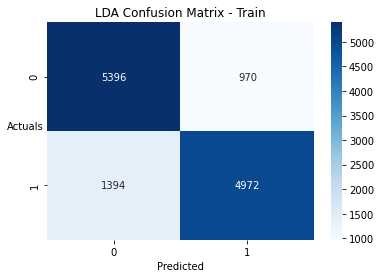

In [340]:
sns.heatmap((metrics.confusion_matrix(y_train_res, pred_class_train)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('LDA Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [341]:
print(metrics.classification_report(y_train_res, pred_class_train))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      6366
           1       0.84      0.78      0.81      6366

    accuracy                           0.81     12732
   macro avg       0.82      0.81      0.81     12732
weighted avg       0.82      0.81      0.81     12732



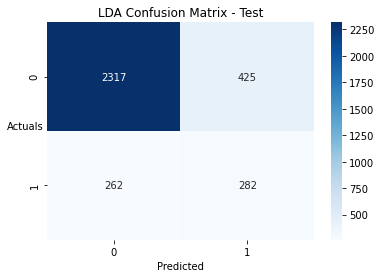

In [342]:
sns.heatmap((metrics.confusion_matrix(y_test, pred_class_test)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('LDA Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [343]:
print(metrics.classification_report(y_test, pred_class_test))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87      2742
           1       0.40      0.52      0.45       544

    accuracy                           0.79      3286
   macro avg       0.65      0.68      0.66      3286
weighted avg       0.82      0.79      0.80      3286



In [344]:
pred_train_lda_prob = model_lda.predict_proba(X_train_res)[:,1]
pred_test_lda_prob = model_lda.predict_proba(X_test)[:,1]

In [345]:
fpr, tpr, thresholds = roc_curve(y_train_res,pred_train_lda_prob)

In [346]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

0.4997614517561391

In [347]:
y_class_pred=[]
for i in range(0,len(pred_train_lda_prob)):
    if np.array(pred_train_lda_prob)[i]>0.49976:
        a=1
    else:
        a=0
    y_class_pred.append(a)

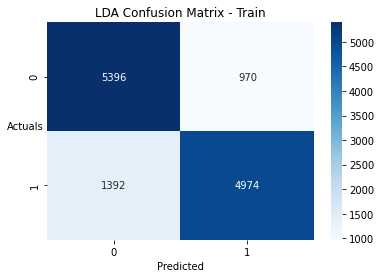

In [348]:
sns.heatmap((metrics.confusion_matrix(y_train_res, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('LDA Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [349]:
print(metrics.classification_report(y_train_res, y_class_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      6366
           1       0.84      0.78      0.81      6366

    accuracy                           0.81     12732
   macro avg       0.82      0.81      0.81     12732
weighted avg       0.82      0.81      0.81     12732



In [267]:
y_class_pred=[]
for i in range(0,len(pred_test_lda_prob)):
    if np.array(pred_test_lda_prob)[i]>0.49976:
        a=1
    else:
        a=0
    y_class_pred.append(a)

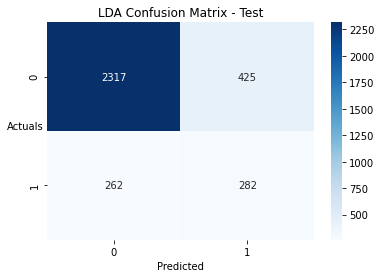

In [269]:
sns.heatmap((metrics.confusion_matrix(y_test, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('LDA Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [270]:
 print(metrics.classification_report(y_test, y_class_pred))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87      2742
           1       0.40      0.52      0.45       544

    accuracy                           0.79      3286
   macro avg       0.65      0.68      0.66      3286
weighted avg       0.82      0.79      0.80      3286



AUC: 0.894


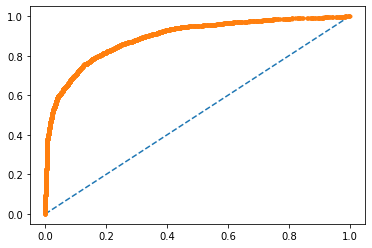

In [352]:
# AUC and ROC for the train data

# predict probabilities
probs = model_lda.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.775


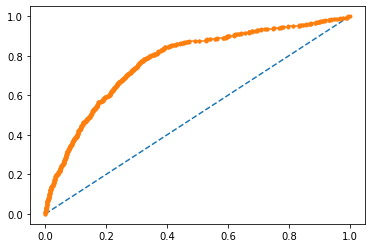

In [351]:
# AUC and ROC for the train data

# predict probabilities
probs = model_lda.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [308]:
# Let us explore the coefficients for each of the independent attributes
for idx, col_name in enumerate(X_train_res.columns):
    print("The coefficient for {} is {}".format(col_name, model_lda.coef_[0][idx]))

The coefficient for Tenure is -0.05041347127453651
The coefficient for CC_Contacted_LY is 0.018826078766005512
The coefficient for rev_per_month is 0.005181984472802369
The coefficient for Complain_ly is 1.0808386666035248
The coefficient for coupon_used_for_payment is 0.055452551223782835
The coefficient for Day_Since_CC_connect is -0.1338080947003704
The coefficient for cashback is 0.00018016518342220395
The coefficient for Payment_Credit Card is -2.8278360367787676
The coefficient for Payment_Debit Card is -2.4237518555675024
The coefficient for Payment_E wallet is -1.6554114969700664
The coefficient for Payment_UPI is -2.6269155819390098
The coefficient for Gender_Male is -0.14725708774511959
The coefficient for account_segment_Regular is -0.6125926062076783
The coefficient for account_segment_Regular Plus is -0.43449223741902443
The coefficient for account_segment_Super is -1.657853825888227
The coefficient for account_segment_Super Plus is -1.7888632876977604
The coefficient for 

## Model 5 - Logistic Regression

In [277]:
default_train = pd.concat([X_train_res, df], axis = 1)
default_test = pd.concat([X_test, y_test], axis = 1)

In [278]:
default_train.columns

Index(['Tenure', 'CC_Contacted_LY', 'rev_per_month', 'Complain_ly',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback',
       'Payment_Credit Card', 'Payment_Debit Card', 'Payment_E wallet',
       'Payment_UPI', 'Gender_Male', 'account_segment_Regular',
       'account_segment_Regular Plus', 'account_segment_Super',
       'account_segment_Super Plus', 'Marital_Status_Married',
       'Marital_Status_Single', 'Login_device_Mobile', 'Churn'],
      dtype='object')

In [281]:
default_train.rename(columns = {'Payment_Credit Card':'Payment_Credit_Card', 'Payment_Debit Card':'Payment_Debit_Card','Payment_E wallet': 'Payment_E_wallet', 'account_segment_Regular Plus': 'account_segment_Regular_Plus', 'account_segment_Super Plus': 'account_segment_Super_Plus' }, inplace = True)

In [294]:
default_test.rename(columns = {'Payment_Credit Card':'Payment_Credit_Card', 'Payment_Debit Card':'Payment_Debit_Card','Payment_E wallet': 'Payment_E_wallet', 'account_segment_Regular Plus': 'account_segment_Regular_Plus', 'account_segment_Super Plus': 'account_segment_Super_Plus' }, inplace = True)

In [282]:
f_1 = 'Churn ~ Tenure + CC_Contacted_LY + rev_per_month + Complain_ly + coupon_used_for_payment + Day_Since_CC_connect + cashback + Payment_Credit_Card + Payment_Debit_Card + Payment_E_wallet + Payment_UPI + Gender_Male + account_segment_Regular + account_segment_Regular_Plus + account_segment_Super + account_segment_Super_Plus + Marital_Status_Married + Marital_Status_Single + Login_device_Mobile'

In [283]:
import statsmodels.formula.api as SM
model_1 = SM.logit(formula = f_1, data=default_train).fit()

Optimization terminated successfully.
         Current function value: 0.408200
         Iterations 7


In [284]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                12732
Model:                          Logit   Df Residuals:                    12712
Method:                           MLE   Df Model:                           19
Date:                Thu, 14 Jul 2022   Pseudo R-squ.:                  0.4111
Time:                        00:06:35   Log-Likelihood:                -5197.2
converged:                       True   LL-Null:                       -8825.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        4.0121      0.125     32.017      0.000       3.766       4.258
Tenure                          -0.0630      0.003    -20.147      0.000      -0.069      -0.057
CC_Contacted_LY                  0.0177      0.003      6.256      0.000       0.012       0.023
rev_per_month                    0.0059      0.002      2.641      0.008       0.002       0.010
Complain_ly                      1.0832      0.055     19.788      0.000       0.976       1.190
coupon_used_for_payment          0.0639      0.015      4.314      0.000       0.035       0.093
Day_Since_CC_connect            -0.1358      0.009    -15.344      0.000      -0.153      -0.118
cashback                         0.0002      0.000      1.803      0.071   -2.09e-05       0.001
Payment_Credit_Card             -2.5455      0.077    -33.146      0.000      -2.696      -2.395
Payment_Debit_Card              -2.2312      0.071    -31.608      0.000      -2.370      -2.093
Payment_E_wallet                -1.5832      0.096    -16.481      0.000      -1.771      -1.395
Payment_UPI                     -2.3591      0.114    -20.651      0.000      -2.583      -2.135
Gender_Male                     -0.1259      0.050     -2.518      0.012      -0.224      -0.028
account_segment_Regular         -0.4242      0.146     -2.899      0.004      -0.711      -0.137
account_segment_Regular_Plus    -0.5324      0.072     -7.394      0.000      -0.673      -0.391
account_segment_Super           -1.5694      0.075    -20.825      0.000      -1.717      -1.422
account_segment_Super_Plus      -1.8372      0.157    -11.711      0.000      -2.145      -1.530
Marital_Status_Married          -1.7143      0.063    -27.105      0.000      -1.838      -1.590
Marital_Status_Single           -0.4356      0.063     -6.890      0.000      -0.559      -0.312
Login_device_Mobile             -0.7980      0.053    -15.022      0.000      -0.902      -0.694
================================================================================================
"""

In [286]:
f_2 = 'Churn ~ Tenure + CC_Contacted_LY + rev_per_month + Complain_ly + coupon_used_for_payment + Day_Since_CC_connect + Payment_Credit_Card + Payment_Debit_Card + Payment_E_wallet + Payment_UPI + Gender_Male + account_segment_Regular + account_segment_Regular_Plus + account_segment_Super + account_segment_Super_Plus + Marital_Status_Married + Marital_Status_Single + Login_device_Mobile'

In [314]:
import statsmodels.formula.api as SM
model_2 = SM.logit(formula = f_2, data=default_train).fit()

Optimization terminated successfully.
         Current function value: 0.408327
         Iterations 7


In [288]:
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                12732
Model:                          Logit   Df Residuals:                    12713
Method:                           MLE   Df Model:                           18
Date:                Thu, 14 Jul 2022   Pseudo R-squ.:                  0.4109
Time:                        00:10:26   Log-Likelihood:                -5198.8
converged:                       True   LL-Null:                       -8825.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        4.0610      0.123     33.150      0.000       3.821       4.301
Tenure                          -0.0630      0.003    -20.164      0.000      -0.069      -0.057
CC_Contacted_LY                  0.0176      0.003      6.227      0.000       0.012       0.023
rev_per_month                    0.0059      0.002      2.630      0.009       0.001       0.010
Complain_ly                      1.0809      0.055     19.755      0.000       0.974       1.188
coupon_used_for_payment          0.0647      0.015      4.368      0.000       0.036       0.094
Day_Since_CC_connect            -0.1358      0.009    -15.351      0.000      -0.153      -0.118
Payment_Credit_Card             -2.5459      0.077    -33.165      0.000      -2.696      -2.395
Payment_Debit_Card              -2.2323      0.071    -31.627      0.000      -2.371      -2.094
Payment_E_wallet                -1.5875      0.096    -16.530      0.000      -1.776      -1.399
Payment_UPI                     -2.3620      0.114    -20.676      0.000      -2.586      -2.138
Gender_Male                     -0.1171      0.050     -2.354      0.019      -0.215      -0.020
account_segment_Regular         -0.4043      0.146     -2.770      0.006      -0.690      -0.118
account_segment_Regular_Plus    -0.5487      0.071     -7.681      0.000      -0.689      -0.409
account_segment_Super           -1.5752      0.075    -20.924      0.000      -1.723      -1.428
account_segment_Super_Plus      -1.8226      0.157    -11.637      0.000      -2.130      -1.516
Marital_Status_Married          -1.7139      0.063    -27.106      0.000      -1.838      -1.590
Marital_Status_Single           -0.4343      0.063     -6.871      0.000      -0.558      -0.310
Login_device_Mobile             -0.7947      0.053    -14.973      0.000      -0.899      -0.691
================================================================================================
"""

In [289]:
y_prob_pred_train = model_2.predict(default_train) 

In [290]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_train)):
    if np.array(y_prob_pred_train)[i]>0.5:
        a=1
    else:
        a=0
    y_class_pred.append(a)

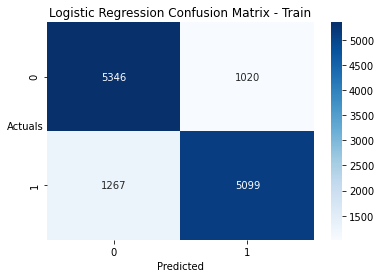

In [291]:
sns.heatmap((metrics.confusion_matrix(default_train['Churn'],y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0)
plt.title('Logistic Regression Confusion Matrix - Train');

In [292]:
print(metrics.classification_report(default_train['Churn'],y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.808     0.840     0.824      6366
           1      0.833     0.801     0.817      6366

    accuracy                          0.820     12732
   macro avg      0.821     0.820     0.820     12732
weighted avg      0.821     0.820     0.820     12732



AUC: 0.897


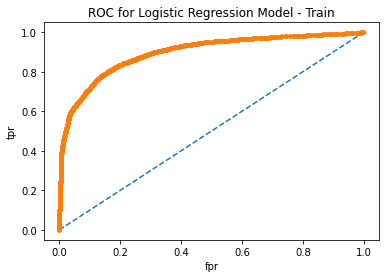

In [300]:
# AUC and ROC for the test data (Holdout sample)

# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(default_train['Churn'], y_prob_pred_train)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(default_train['Churn'], y_prob_pred_train)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC for Logistic Regression Model - Train')
# show the plot
plt.show()

In [295]:
y_prob_pred_test = model_2.predict(default_test)

In [296]:
y_class_pred=[]
for i in range(0,len(y_prob_pred_test)):
    if np.array(y_prob_pred_test)[i]>0.5:
        a=1
    else:
        a=0
    y_class_pred.append(a)

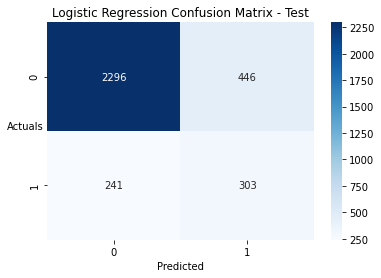

In [297]:
sns.heatmap((metrics.confusion_matrix(default_test['Churn'],y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0)
plt.title('Logistic Regression Confusion Matrix - Test');

In [298]:
print(metrics.classification_report(default_test['Churn'],y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.905     0.837     0.870      2742
           1      0.405     0.557     0.469       544

    accuracy                          0.791      3286
   macro avg      0.655     0.697     0.669      3286
weighted avg      0.822     0.791     0.803      3286



AUC: 0.788


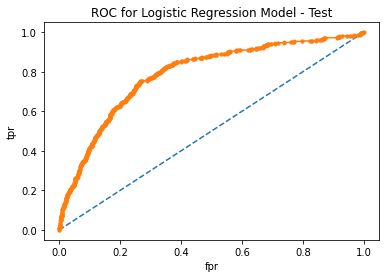

In [301]:
# AUC and ROC for the test data (Holdout sample)

# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(default_test['Churn'], y_prob_pred_test)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(default_test['Churn'], y_prob_pred_test)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC for Logistic Regression Model - Test')
# show the plot
plt.show()

Feature: 0, Score: 4.06096
Feature: 1, Score: -0.06300
Feature: 2, Score: 0.01764
Feature: 3, Score: 0.00587
Feature: 4, Score: 1.08095
Feature: 5, Score: 0.06468
Feature: 6, Score: -0.13580
Feature: 7, Score: -2.54588
Feature: 8, Score: -2.23225
Feature: 9, Score: -1.58749
Feature: 10, Score: -2.36203
Feature: 11, Score: -0.11713
Feature: 12, Score: -0.40428
Feature: 13, Score: -0.54865
Feature: 14, Score: -1.57519
Feature: 15, Score: -1.82265
Feature: 16, Score: -1.71395
Feature: 17, Score: -0.43428
Feature: 18, Score: -0.79469


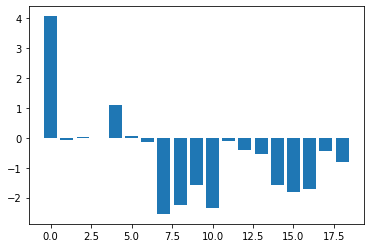

In [321]:
importance = model_2.params
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar(range(0,19,1), importance)
plt.show()

## Ensemble Techniques

### Bagging

In [353]:
from sklearn.ensemble import BaggingClassifier

In [356]:
Bagging_model=BaggingClassifier(base_estimator=best_grid_rf,n_estimators=301,random_state=1)
Bagging_model.fit(X_train_res, y_train_res)

BaggingClassifier(base_estimator=RandomForestClassifier(max_depth=20,
                                                        max_features=8,
                                                        min_samples_leaf=150,
                                                        min_samples_split=450,
                                                        n_estimators=301),
                  n_estimators=301, random_state=1)

In [357]:
# Training Data Class Prediction with a cut-off value of 0.5
pred_class_train = Bagging_model.predict(X_train_res)

# Test Data Class Prediction with a cut-off value of 0.5
pred_class_test = Bagging_model.predict(X_test)

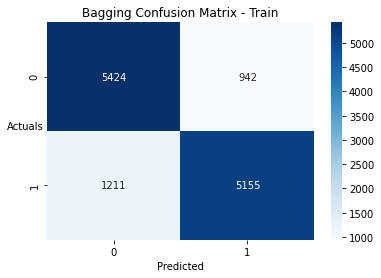

In [358]:
sns.heatmap((metrics.confusion_matrix(y_train_res, pred_class_train)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Bagging Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [359]:
print(metrics.classification_report(y_train_res, pred_class_train))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      6366
           1       0.85      0.81      0.83      6366

    accuracy                           0.83     12732
   macro avg       0.83      0.83      0.83     12732
weighted avg       0.83      0.83      0.83     12732



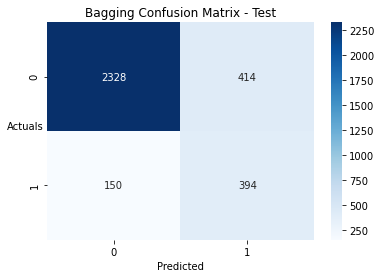

In [360]:
sns.heatmap((metrics.confusion_matrix(y_test, pred_class_test)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Bagging Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [361]:
 print(metrics.classification_report(y_test, pred_class_test))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      2742
           1       0.49      0.72      0.58       544

    accuracy                           0.83      3286
   macro avg       0.71      0.79      0.74      3286
weighted avg       0.86      0.83      0.84      3286



AUC: 0.915


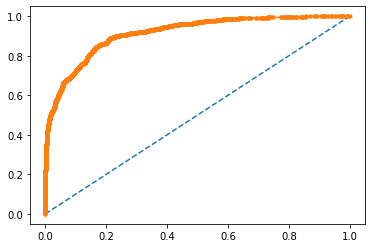

In [362]:
# AUC and ROC for the train data

# predict probabilities
probs = Bagging_model.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.865


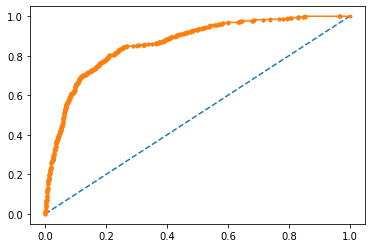

In [363]:
# AUC and ROC for the train data

# predict probabilities
probs = Bagging_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

### Ada Boosting

In [366]:
from sklearn.ensemble import AdaBoostClassifier
abcl = AdaBoostClassifier()
ADB_model= abcl.fit(X_train_res, y_train_res)

In [367]:
pred_class_train = abcl.predict(X_train_res)

pred_class_test = abcl.predict(X_test)

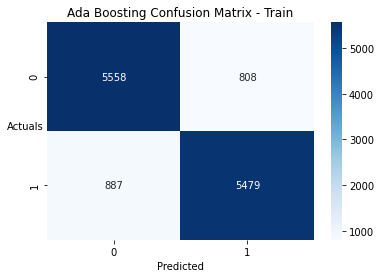

In [368]:
sns.heatmap((metrics.confusion_matrix(y_train_res, pred_class_train)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Ada Boosting Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [369]:
print(metrics.classification_report(y_train_res, pred_class_train))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      6366
           1       0.87      0.86      0.87      6366

    accuracy                           0.87     12732
   macro avg       0.87      0.87      0.87     12732
weighted avg       0.87      0.87      0.87     12732



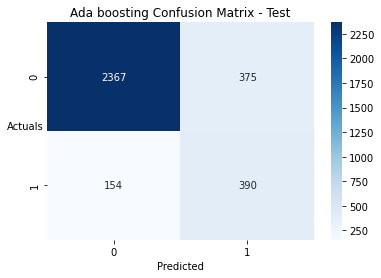

In [370]:
sns.heatmap((metrics.confusion_matrix(y_test, pred_class_test)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Ada boosting Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [371]:
 print(metrics.classification_report(y_test, pred_class_test))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90      2742
           1       0.51      0.72      0.60       544

    accuracy                           0.84      3286
   macro avg       0.72      0.79      0.75      3286
weighted avg       0.87      0.84      0.85      3286



AUC: 0.944


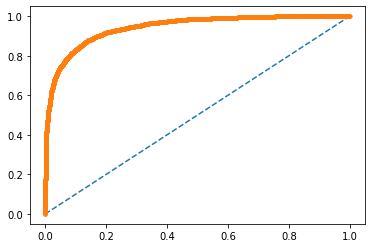

In [372]:
# AUC and ROC for the train data

# predict probabilities
probs = abcl.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.878


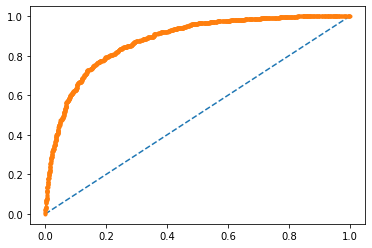

In [373]:
# AUC and ROC for the train data

# predict probabilities
probs = abcl.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

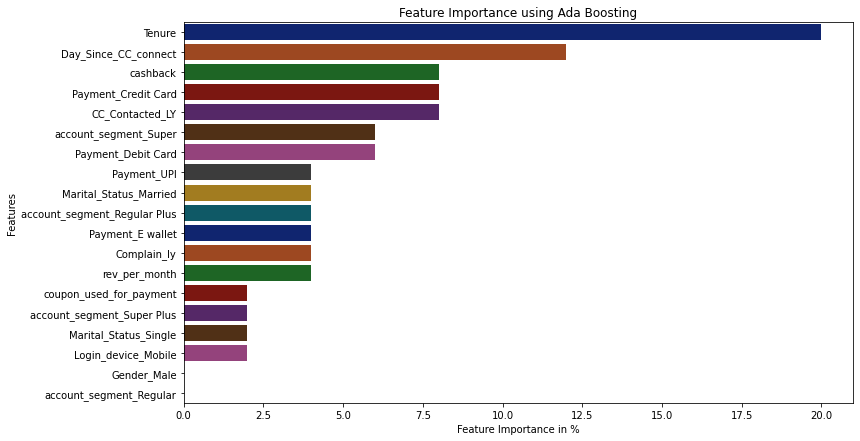

In [374]:
x=pd.DataFrame(abcl.feature_importances_*100,index=X_train_res.columns).sort_values(by=0,ascending=False)
plt.figure(figsize=(12,7))
sns.barplot(x[0],x.index,palette='dark')
plt.xlabel('Feature Importance in %')
plt.ylabel('Features')
plt.title('Feature Importance using Ada Boosting')
plt.show()

### Gradient Boosting

In [375]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier()
gbcl = gbcl.fit(X_train_res, y_train_res)

In [377]:
pred_class_train = gbcl.predict(X_train_res)

pred_class_test = gbcl.predict(X_test)

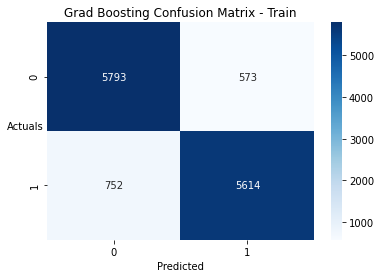

In [378]:
sns.heatmap((metrics.confusion_matrix(y_train_res, pred_class_train)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Grad Boosting Confusion Matrix - Train')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [379]:
print(metrics.classification_report(y_train_res, pred_class_train))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      6366
           1       0.91      0.88      0.89      6366

    accuracy                           0.90     12732
   macro avg       0.90      0.90      0.90     12732
weighted avg       0.90      0.90      0.90     12732



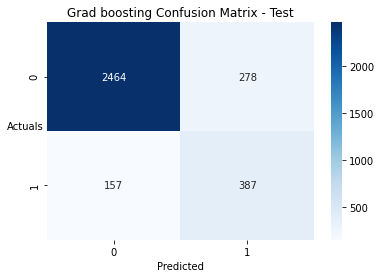

In [380]:
sns.heatmap((metrics.confusion_matrix(y_test, pred_class_test)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.title('Grad boosting Confusion Matrix - Test')
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [381]:
 print(metrics.classification_report(y_test, pred_class_test))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2742
           1       0.58      0.71      0.64       544

    accuracy                           0.87      3286
   macro avg       0.76      0.81      0.78      3286
weighted avg       0.88      0.87      0.87      3286



AUC: 0.963


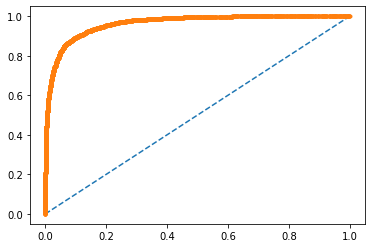

In [382]:
# AUC and ROC for the train data

# predict probabilities
probs = gbcl.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.912


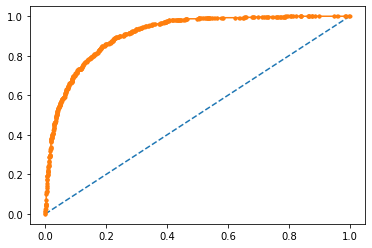

In [383]:
# AUC and ROC for the train data

# predict probabilities
probs = gbcl.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

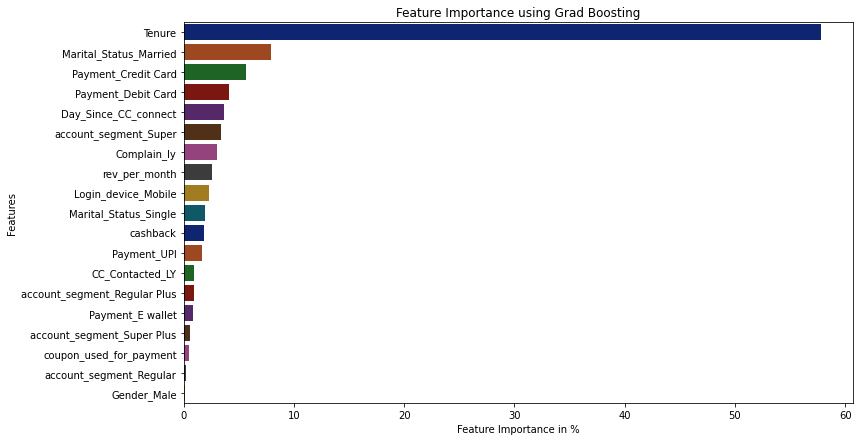

In [384]:
x=pd.DataFrame(gbcl.feature_importances_*100,index=X_train_res.columns).sort_values(by=0,ascending=False)
plt.figure(figsize=(12,7))
sns.barplot(x[0],x.index,palette='dark')
plt.xlabel('Feature Importance in %')
plt.ylabel('Features')
plt.title('Feature Importance using Grad Boosting')
plt.show()

## Model Comparison

Area under the curve for Logistic Regression is 0.9
Area under the curve for LDA is 0.89
Area under the curve for KNN is 0.99
Area under the curve for Naive Bayes is 0.82
Area under the curve for Bagging is 0.91
Area under the curve for Adaptive Boosting is 0.94
Area under the curve for Gradient Boosting is 0.96
Area under the curve for Random Forest is 0.93


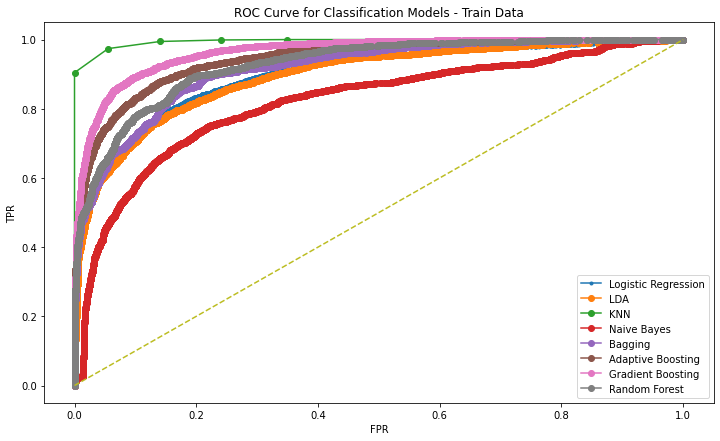

In [385]:
models_names={model_2: 'Logistic Regression',
              model_lda: 'LDA',
              KNN_SM_model:'KNN',
              NB_SM_model:'Naive Bayes',
              Bagging_model: 'Bagging',
              abcl: 'Adaptive Boosting',
              gbcl: 'Gradient Boosting',              
              best_grid_rf: 'Random Forest'}


print('Area under the curve for Logistic Regression is',round(roc_auc_score(default_train['Churn'],model_2.predict(default_train)),2))
print('Area under the curve for LDA is',round(roc_auc_score(y_train_res,model_lda.predict_proba(X_train_res)[:,1]),2))
print('Area under the curve for KNN is',round(roc_auc_score(y_train_res,KNN_SM_model.predict_proba(X_train_res)[:,1]),2))
print('Area under the curve for Naive Bayes is',round(roc_auc_score(y_train_res,NB_SM_model.predict_proba(X_train_res)[:,1]),2))
print('Area under the curve for Bagging is',round(roc_auc_score(y_train_res,Bagging_model.predict_proba(X_train_res)[:,1]),2))
print('Area under the curve for Adaptive Boosting is',round(roc_auc_score(y_train_res,abcl.predict_proba(X_train_res)[:,1]),2))
print('Area under the curve for Gradient Boosting is',round(roc_auc_score(y_train_res,gbcl.predict_proba(X_train_res)[:,1]),2))
print('Area under the curve for Random Forest is',round(roc_auc_score(y_train_res,best_grid_rf.predict_proba(X_train_res)[:,1]),2))

plt.figure(figsize=(12,7))
fpr_dtc, tpr_dtc, thresholds = roc_curve(default_train['Churn'], model_2.predict(default_train))
plt.plot(fpr_dtc, tpr_dtc, marker='.') 

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, model_lda.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o') 

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, KNN_SM_model.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, NB_SM_model.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, Bagging_model.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, abcl.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, gbcl.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_train_res, best_grid_rf.predict_proba(X_train_res)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve for {} - Train Data'.format('Classification Models'))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(models_names.values())
plt.show()

Area under the curve for Logistic Regression is 0.79
Area under the curve for LDA is 0.77
Area under the curve for KNN is 0.87
Area under the curve for Naive Bayes is 0.71
Area under the curve for Bagging is 0.86
Area under the curve for Adaptive Boosting is 0.88
Area under the curve for Gradient Boosting is 0.91
Area under the curve for Random Forest is 0.88


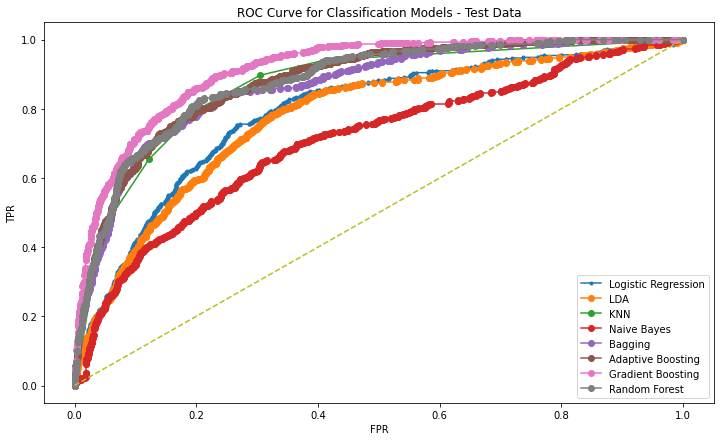

In [386]:
models_names={model_2: 'Logistic Regression',
              model_lda: 'LDA',
              KNN_SM_model:'KNN',
              NB_SM_model:'Naive Bayes',
              Bagging_model: 'Bagging',
              abcl: 'Adaptive Boosting',
              gbcl: 'Gradient Boosting',              
              best_grid_rf: 'Random Forest'}


print('Area under the curve for Logistic Regression is',round(roc_auc_score(default_test['Churn'],model_2.predict(default_test)),2))
print('Area under the curve for LDA is',round(roc_auc_score(y_test,model_lda.predict_proba(X_test)[:,1]),2))
print('Area under the curve for KNN is',round(roc_auc_score(y_test,KNN_SM_model.predict_proba(X_test)[:,1]),2))
print('Area under the curve for Naive Bayes is',round(roc_auc_score(y_test,NB_SM_model.predict_proba(X_test)[:,1]),2))
print('Area under the curve for Bagging is',round(roc_auc_score(y_test,Bagging_model.predict_proba(X_test)[:,1]),2))
print('Area under the curve for Adaptive Boosting is',round(roc_auc_score(y_test,abcl.predict_proba(X_test)[:,1]),2))
print('Area under the curve for Gradient Boosting is',round(roc_auc_score(y_test,gbcl.predict_proba(X_test)[:,1]),2))
print('Area under the curve for Random Forest is',round(roc_auc_score(y_test,best_grid_rf.predict_proba(X_test)[:,1]),2))

plt.figure(figsize=(12,7))
fpr_dtc, tpr_dtc, thresholds = roc_curve(default_test['Churn'], model_2.predict(default_test))
plt.plot(fpr_dtc, tpr_dtc, marker='.') 

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, model_lda.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o') 

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, KNN_SM_model.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, NB_SM_model.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, Bagging_model.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, abcl.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, gbcl.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, best_grid_rf.predict_proba(X_test)[:,1])
plt.plot(fpr_rfc, tpr_rfc, marker='o')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve for {} - Test Data'.format('Classification Models'))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(models_names.values())
plt.show()

In [392]:
model_compare_train = pd.read_excel('Model Compare.xlsx', sheet_name = 'Train', index_col = 'Models')
model_compare_train

,Accuracy - Train,Recall (1) - Train,Precision (1) - Train,F1 Score (1) - Train,AUC Score - Train
Models,,,,,
Naïve Bayes,0.74,0.830,0.700,0.760,0.820
KNN,0.93,0.990,0.880,0.930,0.995
Random Forest,1.00,1.000,1.000,1.000,0.927
LDA,0.81,0.780,0.840,0.810,0.894
Logistic Regression,0.82,0.801,0.833,0.817,0.897
Bagging,0.83,0.810,0.850,0.830,0.915
Adaptive Boosting,0.87,0.860,0.870,0.870,0.944
Gradient Boosting,0.90,0.880,0.910,0.890,0.963


In [393]:
model_compare_test = pd.read_excel('Model Compare.xlsx', sheet_name = 'Test', index_col = 'Models')
model_compare_test

,Accuracy - Test,Recall (1) - Test,Precision (1) - Test,F1 Score (1) - Test,AUC Score - Test
Models,,,,,
Naïve Bayes,0.660,0.680,0.280,0.390,0.705
KNN,0.800,0.800,0.440,0.570,0.867
Random Forest,0.850,0.690,0.540,0.600,0.878
LDA,0.790,0.520,0.400,0.450,0.775
Logistic Regression,0.791,0.557,0.405,0.469,0.788
Bagging,0.830,0.720,0.490,0.580,0.865
Adaptive Boosting,0.840,0.720,0.510,0.600,0.878
Gradient Boosting,0.870,0.710,0.580,0.640,0.912
